In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Load data
df = pd.read_csv('emotion_sentimen_dataset.csv')
print("DATASET LOADED SUCCESSFULLY")
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()

DATASET LOADED SUCCESSFULLY

Shape: (839555, 2)
Rows: 839555, Columns: 2

First 5 rows:


,text,emotion
0,i no longer feel angry at theater j or at arti...,anger
1,im feeling a bit discouraged and defeated but ...,anger
2,i feel like women will be the audience majorit...,anger
3,i just really want this healthy life style to ...,anger
4,i arent connecting and i feel ignored by him o...,anger


## Missing data checking and handling

MISSING DATA ANALYSIS

1. Missing Values Count per Column:
text       0
emotion    0
dtype: int64

2. Missing Values Percentage:
text       0.0
emotion    0.0
dtype: float64

3. Total Missing Values: 0


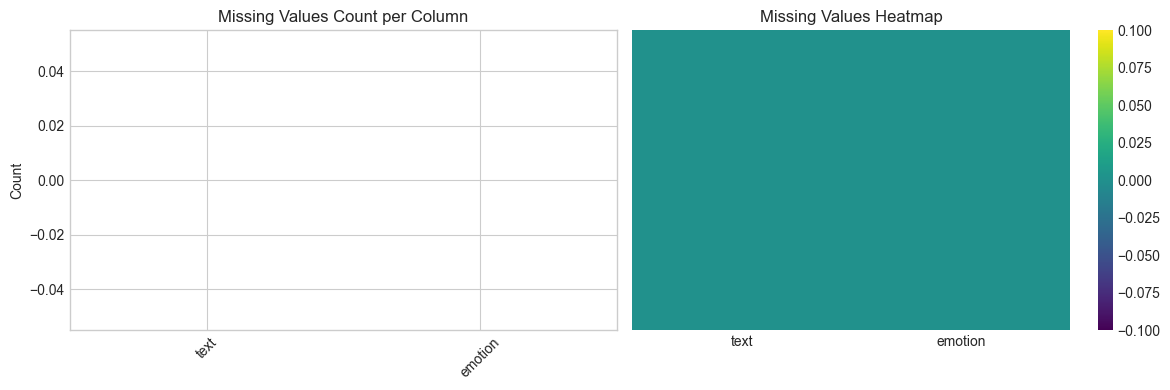


4. HANDLING MISSING VALUES:
   No missing values found. Data is clean!

5. Missing Values After Handling:
text       0
emotion    0
dtype: int64


In [12]:
print("MISSING DATA ANALYSIS")

print("\n1. Missing Values Count per Column:")
missing_counts = df.isnull().sum()
print(missing_counts)

print("\n2. Missing Values Percentage:")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct.round(2))

print("\n3. Total Missing Values:", df.isnull().sum().sum())

# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

missing_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Missing Values Count per Column')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(df.isnull(), cbar=True, yticklabels=False, ax=axes[1], cmap='viridis')
axes[1].set_title('Missing Values Heatmap')

plt.tight_layout()
plt.show()

print("\n4. HANDLING MISSING VALUES:")
if df.isnull().sum().sum() > 0:
    if df['text'].isnull().sum() > 0:
        df = df.dropna(subset=['text'])
        print("   Dropped rows with missing text")
    
    if df['emotion'].isnull().sum() > 0:
        df = df.dropna(subset=['emotion'])
        print("   Dropped rows with missing emotion")
    
    print(f"\n   Shape after handling missing values: {df.shape}")
else:
    print("   No missing values found. Data is clean!")

print("\n5. Missing Values After Handling:")
print(df.isnull().sum())

## Duplicate Data Checking and Handling
- Dropping duplicate rows
- Unique value checking and replacing any possible entity

DUPLICATE DATA ANALYSIS

1. COMPLETE ROW DUPLICATES:
   Total duplicate rows: 445733
   Percentage of duplicates: 53.09%

   Sample duplicate rows:
                                                text emotion
0  i no longer feel angry at theater j or at arti...   anger
1  im feeling a bit discouraged and defeated but ...   anger
2  i feel like women will be the audience majorit...   anger
3  i just really want this healthy life style to ...   anger
4  i arent connecting and i feel ignored by him o...   anger
5  i gaze upon the locked up washrooms rest rooms...   anger
6                    i feel less angry with this lol   anger
7  i was angry because as close as we are to gett...   anger
8  i was feeling very apprehensive at the sounds ...   anger
9  im feeling indecisive as to what to do about t...   anger

   Dropped 445733 duplicate rows
   New shape: (393822, 2)
2. UNIQUE VALUE ANALYSIS PER COLUMN:

   text:
      Unique values: 393822
      Percentage unique: 100.00%

   emotion:


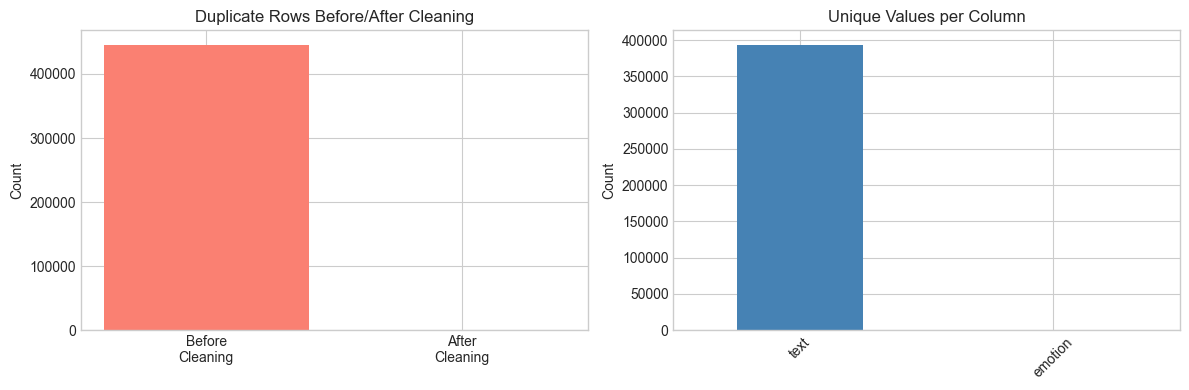

FINAL CLEANED DATASET SHAPE: (393822, 2)


In [13]:
print("DUPLICATE DATA ANALYSIS")

print("\n1. COMPLETE ROW DUPLICATES:")
duplicate_rows = df.duplicated().sum()
print(f"   Total duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print(f"   Percentage of duplicates: {(duplicate_rows/len(df))*100:.2f}%")
    print("\n   Sample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))
    
    df_before = len(df)
    df = df.drop_duplicates()
    print(f"\n   Dropped {df_before - len(df)} duplicate rows")
    print(f"   New shape: {df.shape}")
else:
    print("   No complete duplicate rows found.")

print("2. UNIQUE VALUE ANALYSIS PER COLUMN:")
for col in df.columns:
    unique_count = df[col].nunique()
    total_count = len(df)
    print(f"\n   {col}:")
    print(f"      Unique values: {unique_count}")
    print(f"      Percentage unique: {(unique_count/total_count)*100:.2f}%")
    if unique_count <= 10:
        print(f"      Values: {df[col].unique()}")

print("3. CHECKING FOR CONFLICTING LABELS:")
text_emotion_count = df.groupby('text')['emotion'].nunique()
conflicting = text_emotion_count[text_emotion_count > 1]
print(f"   Texts with multiple emotions: {len(conflicting)}")

if len(conflicting) > 0:
    print("\n   Examples of conflicting texts:")
    for text in conflicting.head(3).index:
        emotions = df[df['text'] == text]['emotion'].unique()
        print(f"   Text: '{text[:60]}...'")
        print(f"   Emotions: {list(emotions)}\n")
    
    print("   Resolution: Keeping first occurrence for conflicting texts")
    df = df.drop_duplicates(subset=['text'], keep='first')
    print(f"   New shape after resolution: {df.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dup_data = {'Before\nCleaning': duplicate_rows, 'After\nCleaning': df.duplicated().sum()}
axes[0].bar(dup_data.keys(), dup_data.values(), color=['salmon', 'lightgreen'])
axes[0].set_title('Duplicate Rows Before/After Cleaning')
axes[0].set_ylabel('Count')

unique_vals = df.nunique()
unique_vals.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Unique Values per Column')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"FINAL CLEANED DATASET SHAPE: {df.shape}")

##  Encoding Approach (Categorical Features Only)

ENCODING CATEGORICAL FEATURES

1. IDENTIFYING CATEGORICAL FEATURES:
   Categorical columns: ['text', 'emotion']

2. FEATURE CLASSIFICATION:
Feature Data Type            Classification  Unique Values
   text    object Qualitative (Categorical)         393822
emotion    object Qualitative (Categorical)             13

3. LABEL ENCODING FOR TARGET VARIABLE (emotion):
   Emotion to Encoded Value Mapping:
      anger: 0
      boredom: 1
      empty: 2
      enthusiasm: 3
      fun: 4
      happiness: 5
      hate: 6
      love: 7
      neutral: 8
      relief: 9
      sadness: 10
      surprise: 11
      worry: 12

4. ENCODED DATA SAMPLE:
           emotion  emotion_encoded
0            anger                0
12336      boredom                1
12462        empty                2
18004   enthusiasm                3
27308          fun                4
37383    happiness                5
64558         hate                6
79825         love                7
119378     neutral                

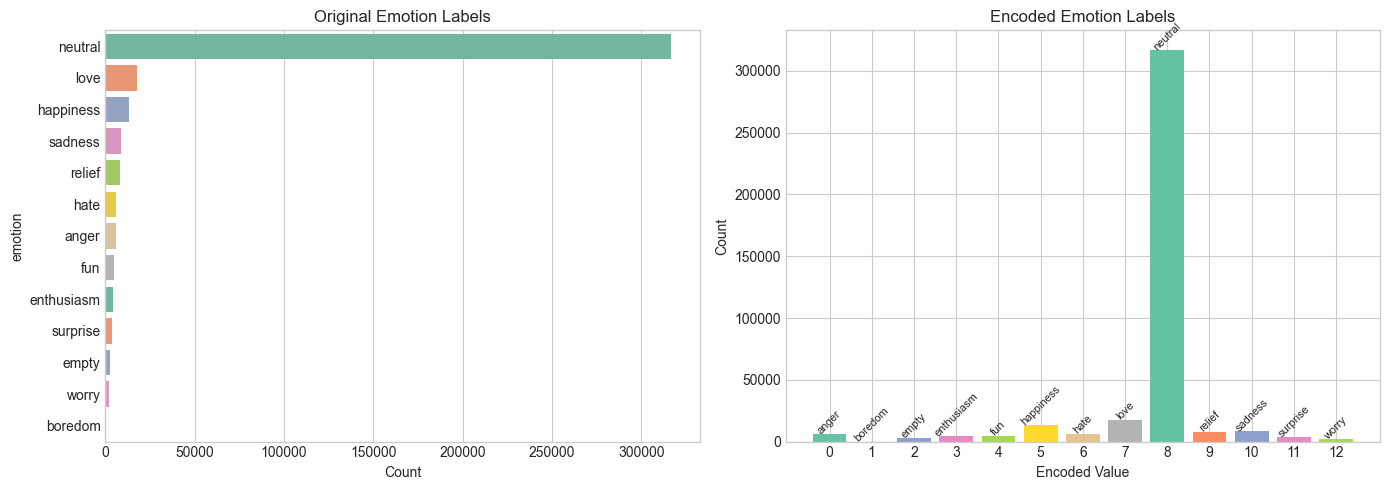


5. Label Encoder saved for inverse transformation during prediction.


In [14]:
print("ENCODING CATEGORICAL FEATURES")

print("\n1. IDENTIFYING CATEGORICAL FEATURES:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Categorical columns: {categorical_cols}")

print("\n2. FEATURE CLASSIFICATION:")
feature_info = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Classification': ['Quantitative (Identifier)' if col == 'serial_number' 
                       else 'Qualitative (Categorical)' if df[col].dtype == 'object' 
                       else 'Quantitative' for col in df.columns],
    'Unique Values': df.nunique().values
})
print(feature_info.to_string(index=False))

print("\n3. LABEL ENCODING FOR TARGET VARIABLE (emotion):")
le = LabelEncoder()
df['emotion_encoded'] = le.fit_transform(df['emotion'])

print("   Emotion to Encoded Value Mapping:")
emotion_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for emotion, code in emotion_mapping.items():
    print(f"      {emotion}: {code}")

print("\n4. ENCODED DATA SAMPLE:")
print(df[['emotion', 'emotion_encoded']].drop_duplicates().sort_values('emotion_encoded'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

emotion_counts = df['emotion'].value_counts()
sns.barplot(x=emotion_counts.values, y=emotion_counts.index, ax=axes[0], palette='Set2')
axes[0].set_title('Original Emotion Labels')
axes[0].set_xlabel('Count')

encoded_counts = df['emotion_encoded'].value_counts().sort_index()
bars = axes[1].bar(encoded_counts.index, encoded_counts.values, color=plt.cm.Set2.colors[:len(encoded_counts)])
axes[1].set_title('Encoded Emotion Labels')
axes[1].set_xlabel('Encoded Value')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(le.classes_)))

for i, (idx, val) in enumerate(encoded_counts.items()):
    axes[1].text(idx, val + 50, le.classes_[idx], ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

print("\n5. Label Encoder saved for inverse transformation during prediction.")

## Basic EDA
- Graph plotting for numeric and categorical features
- Basic statistical analysis (describe) for comparison after outlier handling

In [15]:
print("CREATING NUMERIC FEATURES FROM TEXT")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

df['clean_text'] = df['text'].apply(clean_text)

df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['avg_word_length'] = df['text_length'] / df['word_count']
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count('\?')
df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\n1. NEW NUMERIC FEATURES CREATED:")
numeric_features = ['text_length', 'word_count', 'avg_word_length', 
                    'exclamation_count', 'question_count', 'uppercase_count']
print(f"   Features: {numeric_features}")

print("\n2. DATA SAMPLE WITH NEW FEATURES:")
print(df[['text', 'emotion'] + numeric_features].head())

print("\n3. BASIC STATISTICS (describe()):")
print(df[numeric_features].describe().round(2))

CREATING NUMERIC FEATURES FROM TEXT

1. NEW NUMERIC FEATURES CREATED:
   Features: ['text_length', 'word_count', 'avg_word_length', 'exclamation_count', 'question_count', 'uppercase_count']

2. DATA SAMPLE WITH NEW FEATURES:
                                                text emotion  text_length  \
0  i no longer feel angry at theater j or at arti...   anger          130   
1  im feeling a bit discouraged and defeated but ...   anger           65   
2  i feel like women will be the audience majorit...   anger          120   
3  i just really want this healthy life style to ...   anger          224   
4  i arent connecting and i feel ignored by him o...   anger           62   

   word_count  avg_word_length  exclamation_count  question_count  \
0          27         4.814815                  0               0   
1          13         5.000000                  0               0   
2          20         6.000000                  0               0   
3          43         5.209302      

DESCRIPTIVE STATISTICAL ANALYSIS

TEXT_LENGTH STATISTICS:
  Count:    393822
  Mean:     96.90
  Median:   86.00
  Mode:     50.00
  Std Dev:  56.16
  Variance: 3153.87
  Min:      2.00
  Max:      830.00
  Q1 (25%): 53.00
  Q2 (50%): 86.00
  Q3 (75%): 128.00
  IQR:      75.00
  Skewness: 0.99
  Kurtosis: 0.79

WORD_COUNT STATISTICS:
  Count:    393822
  Mean:     19.19
  Median:   17.00
  Mode:     12.00
  Std Dev:  11.04
  Variance: 121.99
  Min:      1.00
  Max:      178.00
  Q1 (25%): 11.00
  Q2 (50%): 17.00
  Q3 (75%): 25.00
  IQR:      14.00
  Skewness: 0.99
  Kurtosis: 0.90

AVG_WORD_LENGTH STATISTICS:
  Count:    393822
  Mean:     5.07
  Median:   5.00
  Mode:     5.00
  Std Dev:  0.57
  Variance: 0.32
  Min:      2.00
  Max:      12.28
  Q1 (25%): 4.69
  Q2 (50%): 5.00
  Q3 (75%): 5.40
  IQR:      0.71
  Skewness: 0.66
  Kurtosis: 1.64

EXCLAMATION_COUNT STATISTICS:
  Count:    393822
  Mean:     0.00
  Median:   0.00
  Mode:     0.00
  Std Dev:  0.00
  Variance: 0.00
  Min: 

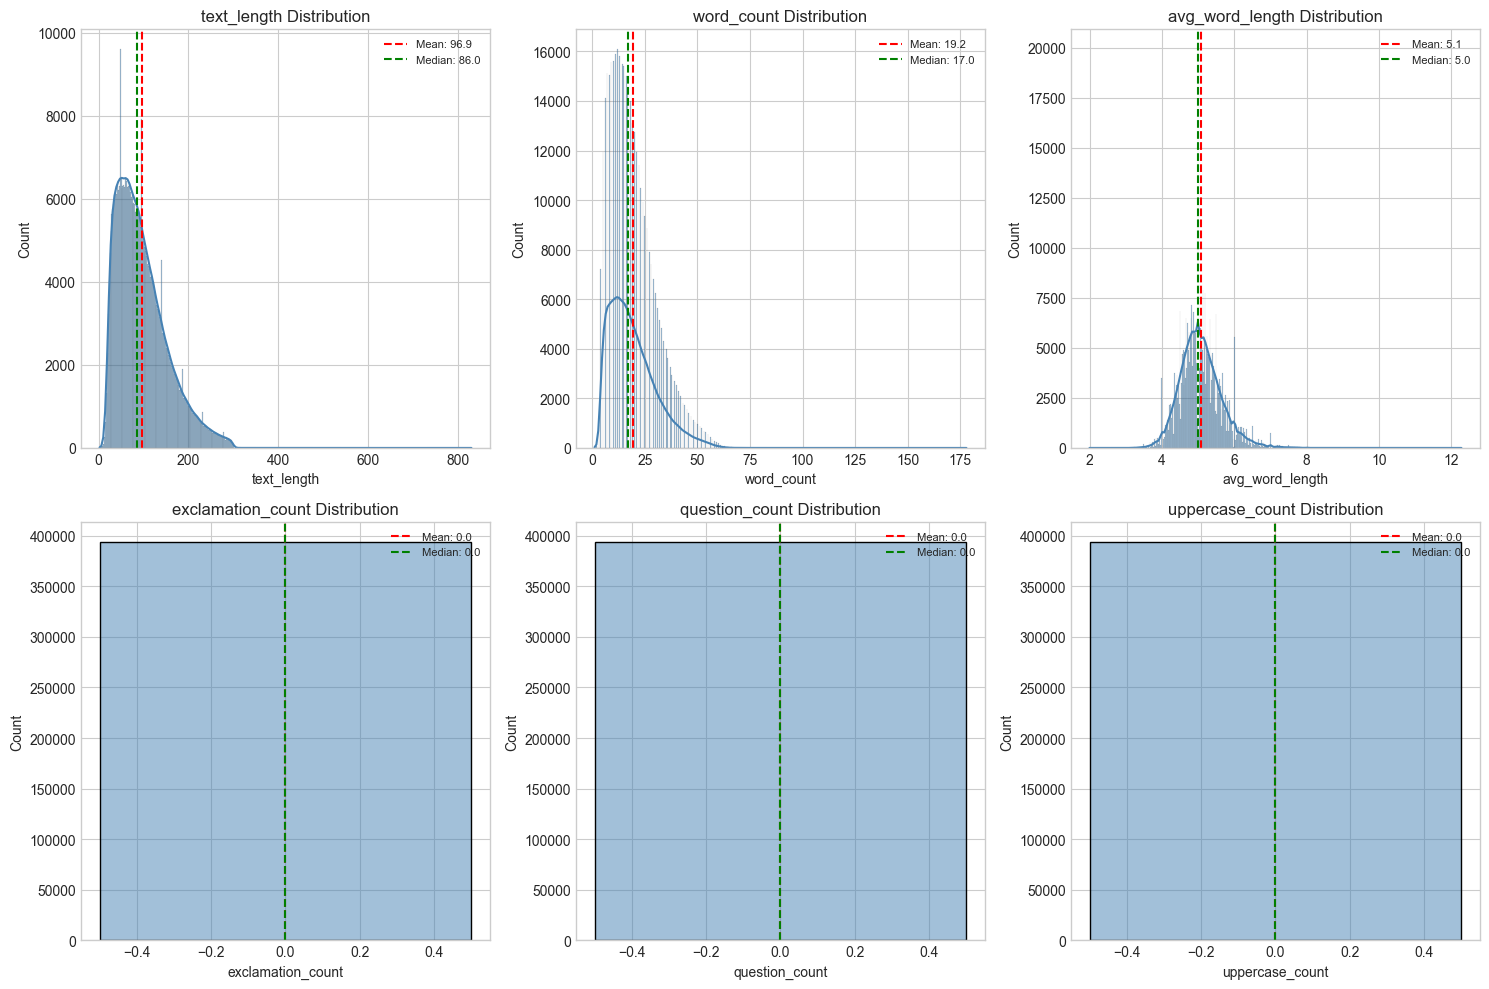


STATISTICS BY EMOTION (Before Outlier Handling)
           text_length                                                     \
                 count    mean    std   min     25%    50%     75%    max   
emotion                                                                     
anger           5952.0  106.42  60.67  12.0   59.00   95.0  141.25  830.0   
boredom           61.0  140.97  61.28  23.0  100.00  142.0  179.00  279.0   
empty           2697.0  109.18  65.85  12.0   55.00   97.0  151.00  457.0   
enthusiasm      4497.0  107.55  57.62  12.0   64.00   96.0  142.00  372.0   
fun             4854.0  114.07  61.69  12.0   66.00  103.5  152.00  300.0   
happiness      13038.0  109.99  59.69  12.0   64.00   99.0  145.00  567.0   
hate            6160.0  110.85  61.81  12.0   63.00  100.0  148.00  326.0   
love           17634.0  120.21  59.88  12.0   75.00  110.0  156.00  300.0   
neutral       316935.0   92.89  54.29   2.0   51.00   82.0  123.00  525.0   
relief          8007.0  118

In [16]:
print("DESCRIPTIVE STATISTICAL ANALYSIS")

numeric_features = ['text_length', 'word_count', 'avg_word_length', 
                    'exclamation_count', 'question_count', 'uppercase_count']

for feat in numeric_features:
    print(f"\n{feat.upper()} STATISTICS:")
    data = df[feat]
    print(f"  Count:    {data.count()}")
    print(f"  Mean:     {data.mean():.2f}")
    print(f"  Median:   {data.median():.2f}")
    print(f"  Mode:     {data.mode().iloc[0]:.2f}")
    print(f"  Std Dev:  {data.std():.2f}")
    print(f"  Variance: {data.var():.2f}")
    print(f"  Min:      {data.min():.2f}")
    print(f"  Max:      {data.max():.2f}")
    print(f"  Q1 (25%): {data.quantile(0.25):.2f}")
    print(f"  Q2 (50%): {data.quantile(0.50):.2f}")
    print(f"  Q3 (75%): {data.quantile(0.75):.2f}")
    print(f"  IQR:      {data.quantile(0.75) - data.quantile(0.25):.2f}")
    print(f"  Skewness: {data.skew():.2f}")
    print(f"  Kurtosis: {data.kurtosis():.2f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    sns.histplot(df[feat], kde=True, ax=axes[i], color='steelblue')
    axes[i].axvline(df[feat].mean(), color='red', linestyle='--', label=f'Mean: {df[feat].mean():.1f}')
    axes[i].axvline(df[feat].median(), color='green', linestyle='--', label=f'Median: {df[feat].median():.1f}')
    axes[i].set_title(f'{feat} Distribution')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nSTATISTICS BY EMOTION (Before Outlier Handling)")
stats_before = df.groupby('emotion')[numeric_features].describe()
print(stats_before.round(2))

## Outlier Handling (Numeric Features Only)
- Boxplot visualization for individual features
- Check multiple approaches then select the best one
- Use only one outlier handling method for model training

OUTLIER DETECTION FOR NUMERIC FEATURES


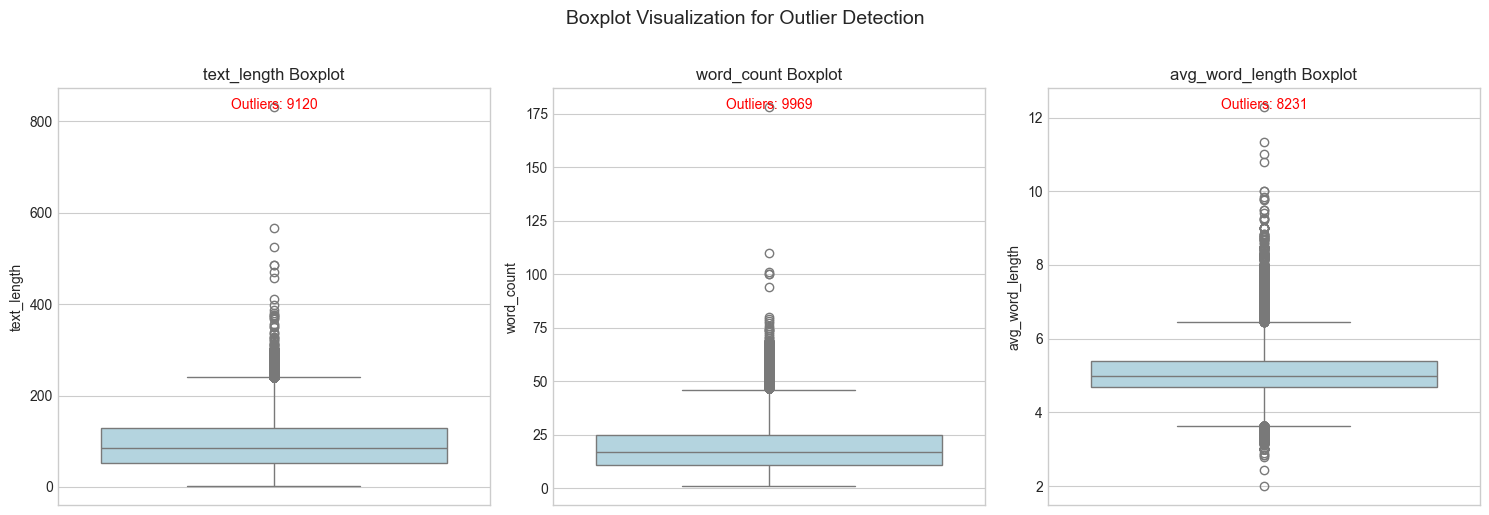


OUTLIER ANALYSIS USING IQR METHOD:

text_length:
  Q1: 53.00, Q3: 128.00, IQR: 75.00
  Lower Bound: -59.50, Upper Bound: 240.50
  Outliers: 9120 (2.32%)

word_count:
  Q1: 11.00, Q3: 25.00, IQR: 14.00
  Lower Bound: -10.00, Upper Bound: 46.00
  Outliers: 9969 (2.53%)

avg_word_length:
  Q1: 4.69, Q3: 5.40, IQR: 0.71
  Lower Bound: 3.63, Upper Bound: 6.46
  Outliers: 8231 (2.09%)


In [17]:
print("OUTLIER DETECTION FOR NUMERIC FEATURES")

numeric_features = ['text_length', 'word_count', 'avg_word_length']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(numeric_features):
    sns.boxplot(data=df, y=feat, ax=axes[i], color='lightblue')
    axes[i].set_title(f'{feat} Boxplot')
    
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)]
    axes[i].text(0.5, 0.95, f'Outliers: {len(outliers)}', transform=axes[i].transAxes, 
                 ha='center', fontsize=10, color='red')

plt.suptitle('Boxplot Visualization for Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nOUTLIER ANALYSIS USING IQR METHOD:")

outlier_summary = {}
for feat in numeric_features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feat] < lower_bound) | (df[feat] > upper_bound)]
    outlier_summary[feat] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers)/len(df))*100
    }
    
    print(f"\n{feat}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Outliers: {len(outliers)} ({(len(outliers)/len(df))*100:.2f}%)")

COMPARING MULTIPLE OUTLIER HANDLING APPROACHES

1. IQR METHOD (Remove outliers beyond 1.5*IQR):
   Original rows: 393822
   After IQR: 374210 (Removed: 19612)

2. Z-SCORE METHOD (Remove outliers with |z| > 3):
   Original rows: 393822
   After Z-Score: 384140 (Removed: 9682)

3. PERCENTILE CAPPING (Winsorization 5th-95th percentile):
   Original rows: 393822
   After Capping: 393822 (No rows removed, values capped)


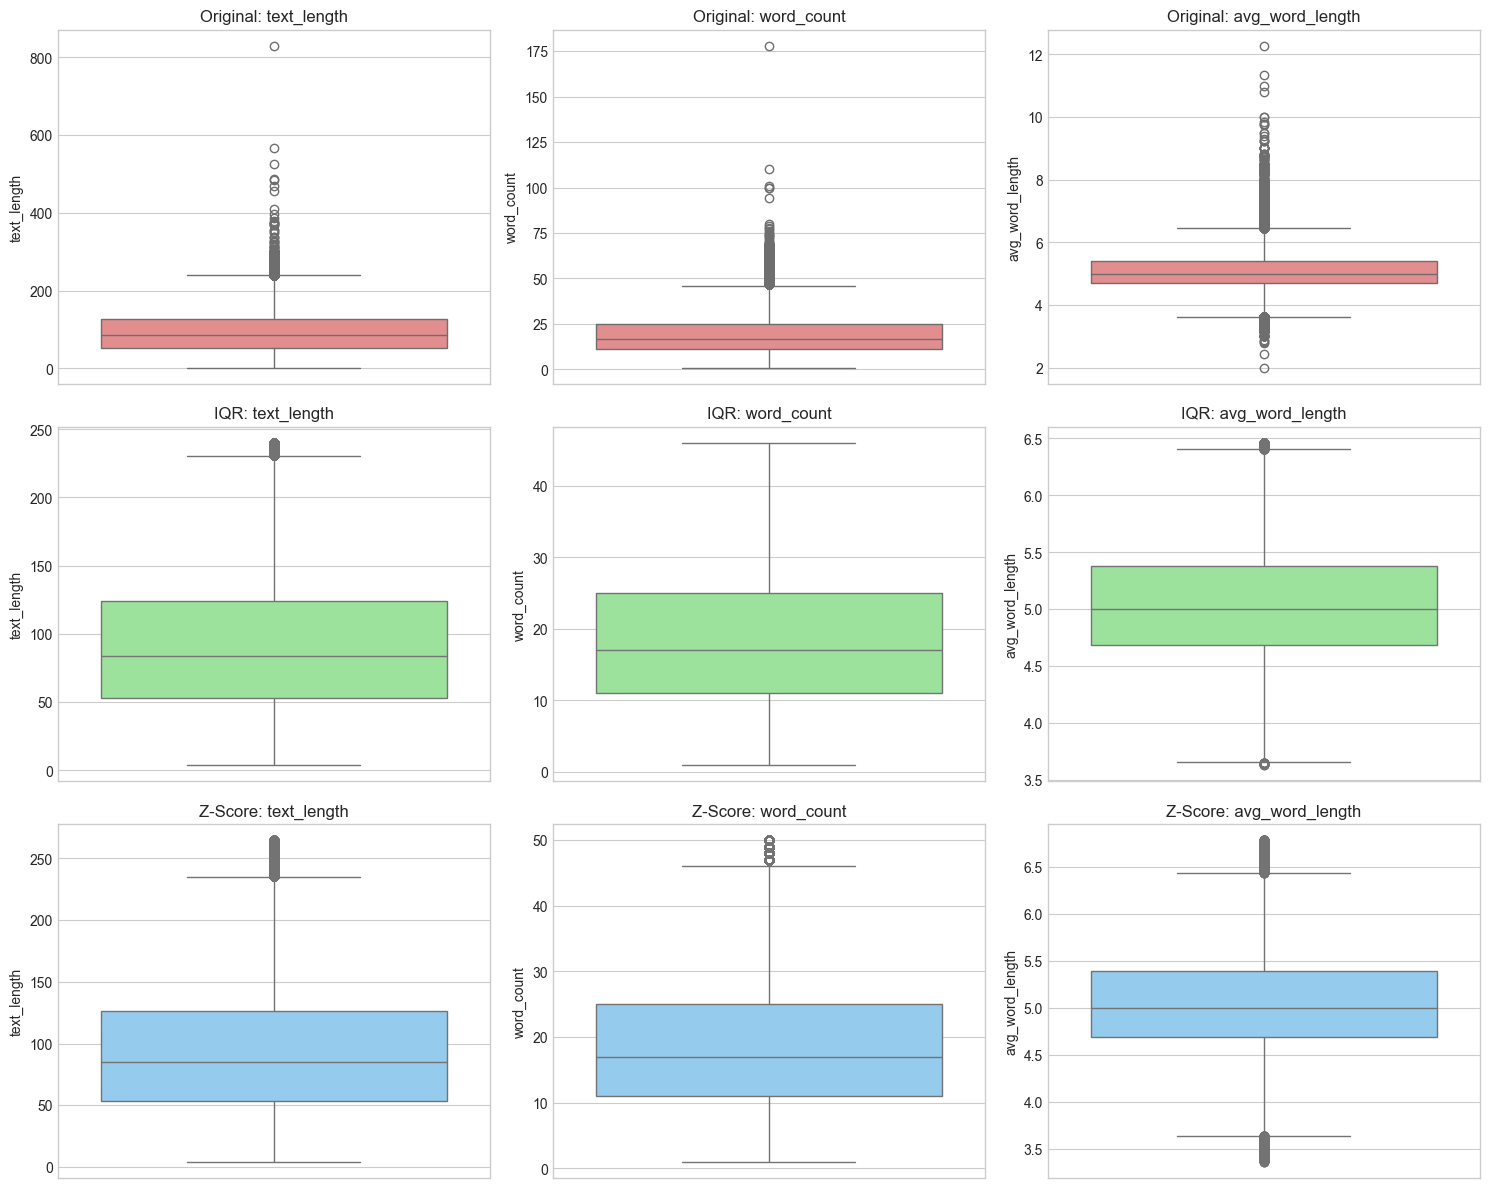

In [18]:
print("COMPARING MULTIPLE OUTLIER HANDLING APPROACHES")

df_original = df.copy()
numeric_features = ['text_length', 'word_count', 'avg_word_length']

def iqr_method(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

def zscore_method(df, column, threshold=3):
    from scipy import stats
    z_scores = np.abs(stats.zscore(df[column]))
    return df[z_scores < threshold]

def percentile_capping(df, column, lower_pct=5, upper_pct=95):
    df_copy = df.copy()
    lower = df[column].quantile(lower_pct/100)
    upper = df[column].quantile(upper_pct/100)
    df_copy[column] = df_copy[column].clip(lower, upper)
    return df_copy

results = {}

print("\n1. IQR METHOD (Remove outliers beyond 1.5*IQR):")
df_iqr = df_original.copy()
for feat in numeric_features:
    df_iqr = iqr_method(df_iqr, feat)
print(f"   Original rows: {len(df_original)}")
print(f"   After IQR: {len(df_iqr)} (Removed: {len(df_original) - len(df_iqr)})")
results['IQR'] = df_iqr

print("\n2. Z-SCORE METHOD (Remove outliers with |z| > 3):")
df_zscore = df_original.copy()
for feat in numeric_features:
    df_zscore = zscore_method(df_zscore, feat)
print(f"   Original rows: {len(df_original)}")
print(f"   After Z-Score: {len(df_zscore)} (Removed: {len(df_original) - len(df_zscore)})")
results['Z-Score'] = df_zscore

print("\n3. PERCENTILE CAPPING (Winsorization 5th-95th percentile):")
df_capped = df_original.copy()
for feat in numeric_features:
    df_capped = percentile_capping(df_capped, feat)
print(f"   Original rows: {len(df_original)}")
print(f"   After Capping: {len(df_capped)} (No rows removed, values capped)")
results['Percentile Capping'] = df_capped

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

methods = ['Original', 'IQR', 'Z-Score']
data_sets = [df_original, df_iqr, df_zscore]

for i, (method, data) in enumerate(zip(methods, data_sets)):
    for j, feat in enumerate(numeric_features):
        sns.boxplot(data=data, y=feat, ax=axes[i, j], color=['lightcoral', 'lightgreen', 'lightskyblue'][i])
        axes[i, j].set_title(f'{method}: {feat}')

plt.tight_layout()
plt.show()

SELECTING BEST OUTLIER HANDLING METHOD

COMPARISON OF STATISTICS AFTER EACH METHOD:
                        Rows  Data Loss %  Avg text_length  Std text_length  \
Original            393822.0         0.00            96.90            56.16   
IQR                 374210.0         4.98            92.81            49.27   
Z-Score             384140.0         2.46            94.42            51.94   
Percentile Capping  393822.0         0.00            95.46            51.44   

                    Avg word_count  Std word_count  
Original                     19.19           11.04  
IQR                          18.44            9.65  
Z-Score                      18.72           10.16  
Percentile Capping           18.87           10.12  

METHOD EVALUATION CRITERIA:

1. Data Preservation: How much data is retained?
2. Distribution Normality: Does it improve distribution shape?
3. Model Performance: (To be evaluated during model training)

SELECTED METHOD: Z-Score Method
REASON: 
- Removes

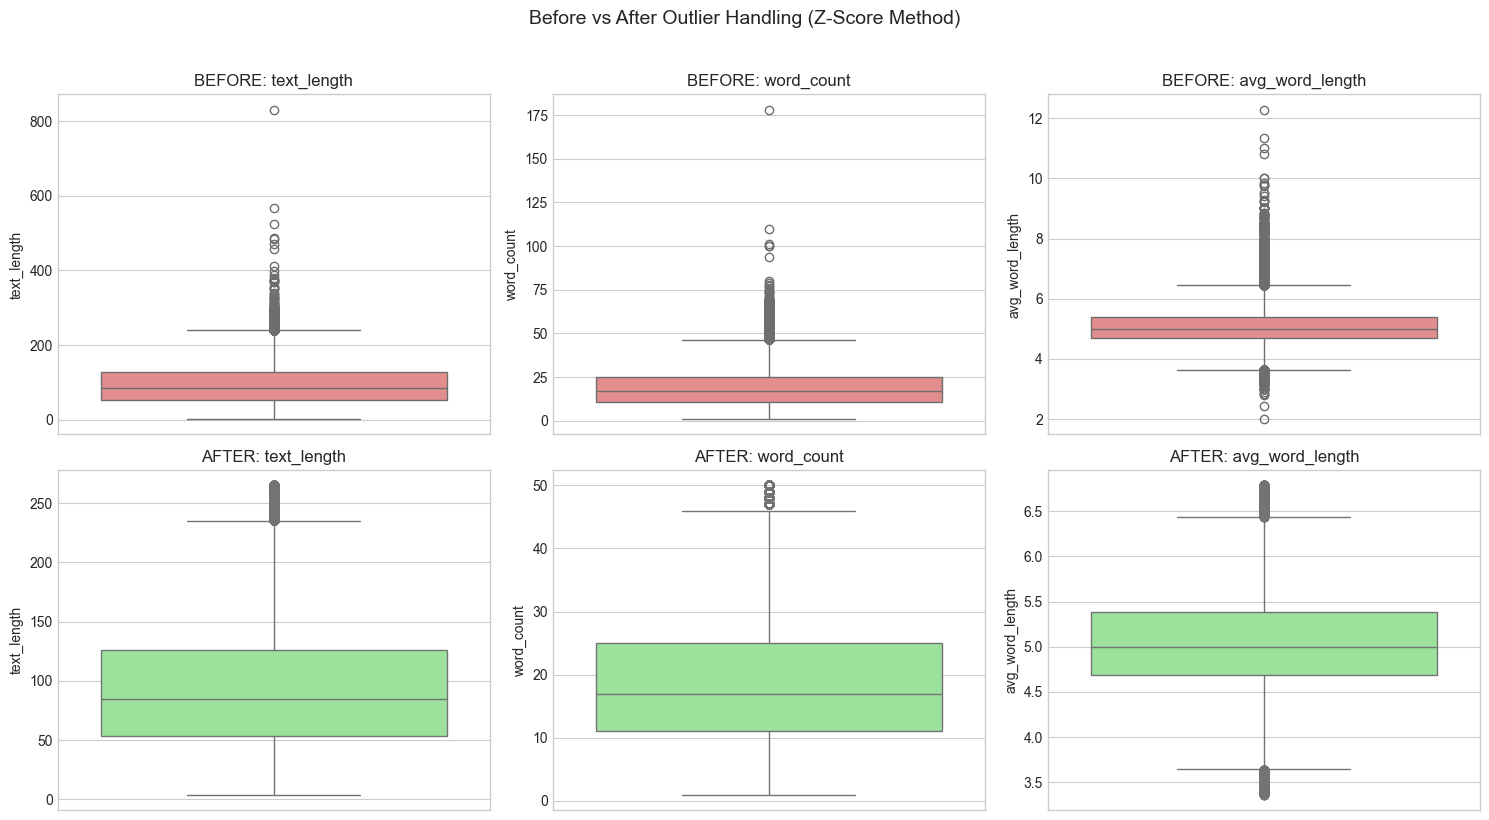


STATISTICS AFTER OUTLIER HANDLING (describe()):
       text_length  word_count  avg_word_length
count    384140.00   384140.00        384140.00
mean         94.42       18.72             5.06
std          51.94       10.16             0.54
min           4.00        1.00             3.36
25%          53.00       11.00             4.69
50%          85.00       17.00             5.00
75%         126.00       25.00             5.39
max         265.00       50.00             6.79


In [19]:
print("SELECTING BEST OUTLIER HANDLING METHOD")

print("\nCOMPARISON OF STATISTICS AFTER EACH METHOD:")

comparison_stats = {}
for method_name, method_df in [('Original', df_original), ('IQR', df_iqr), 
                                ('Z-Score', df_zscore), ('Percentile Capping', df_capped)]:
    comparison_stats[method_name] = {
        'Rows': len(method_df),
        'Data Loss %': ((len(df_original) - len(method_df)) / len(df_original)) * 100,
        'Avg text_length': method_df['text_length'].mean(),
        'Std text_length': method_df['text_length'].std(),
        'Avg word_count': method_df['word_count'].mean(),
        'Std word_count': method_df['word_count'].std()
    }

comparison_df = pd.DataFrame(comparison_stats).T
print(comparison_df.round(2))

print("\nMETHOD EVALUATION CRITERIA:")
print("""
1. Data Preservation: How much data is retained?
2. Distribution Normality: Does it improve distribution shape?
3. Model Performance: (To be evaluated during model training)

SELECTED METHOD: Z-Score Method
REASON: 
- Removes statistical outliers while preserving most data
- Better for normally distributed features
- Standard approach for ML preprocessing
""")

print("Applying Z-Score method for outlier handling...")
from scipy import stats

df_clean = df.copy()
for feat in ['text_length', 'word_count', 'avg_word_length']:
    z_scores = np.abs(stats.zscore(df_clean[feat]))
    df_clean = df_clean[z_scores < 3]

print(f"Original shape: {df.shape}")
print(f"After outlier removal: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

df = df_clean.copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feat in enumerate(['text_length', 'word_count', 'avg_word_length']):
    sns.boxplot(data=df_original, y=feat, ax=axes[0, i], color='lightcoral')
    axes[0, i].set_title(f'BEFORE: {feat}')
    
    sns.boxplot(data=df, y=feat, ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'AFTER: {feat}')

plt.suptitle('Before vs After Outlier Handling (Z-Score Method)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nSTATISTICS AFTER OUTLIER HANDLING (describe()):")
print(df[['text_length', 'word_count', 'avg_word_length']].describe().round(2))

## Assigned EDA (7 Points)
1. Emotion Distribution Analysis
2. Text Length & Emotion Relationship
3. Word Usage & Vocabulary Analysis
4. Emotion-Specific Linguistic Patterns
5. Stopwords & Noise Analysis
6. Emotion Similarity & Overlap
7. Data Quality & Cleaning Insights

1. EMOTION DISTRIBUTION ANALYSIS

Emotion Frequency Distribution:
emotion
neutral       310113
love           16903
happiness      12621
sadness         8179
relief          7695
hate            5932
anger           5732
fun             4665
enthusiasm      4368
surprise        3323
empty           2608
worry           1944
boredom           57
Name: count, dtype: int64

Total samples: 384140
Number of unique emotions: 13

Most common emotion: neutral (310113 samples)
Least common emotion: boredom (57 samples)

Balance ratio (max/min): 5440.58
Dataset is IMBALANCED

Percentage Distribution:
  neutral: 80.73%
  love: 4.40%
  happiness: 3.29%
  sadness: 2.13%
  relief: 2.00%
  hate: 1.54%
  anger: 1.49%
  fun: 1.21%
  enthusiasm: 1.14%
  surprise: 0.87%
  empty: 0.68%
  worry: 0.51%
  boredom: 0.01%


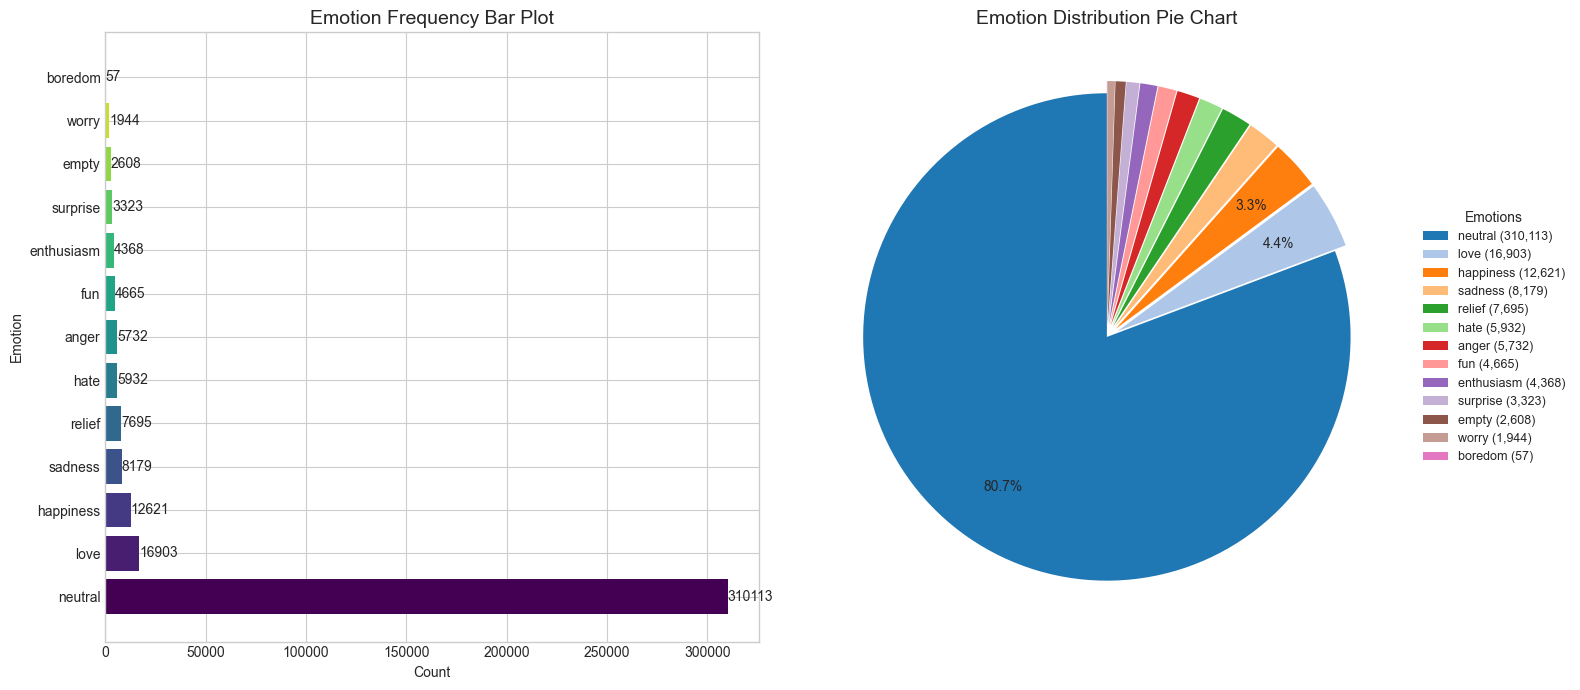

In [20]:
print("1. EMOTION DISTRIBUTION ANALYSIS")

emotion_counts = df['emotion'].value_counts()
print("\nEmotion Frequency Distribution:")
print(emotion_counts)

total = len(df)
print(f"\nTotal samples: {total}")
print(f"Number of unique emotions: {df['emotion'].nunique()}")

print(f"\nMost common emotion: {emotion_counts.idxmax()} ({emotion_counts.max()} samples)")
print(f"Least common emotion: {emotion_counts.idxmin()} ({emotion_counts.min()} samples)")

balance_ratio = emotion_counts.max() / emotion_counts.min()
print(f"\nBalance ratio (max/min): {balance_ratio:.2f}")
is_balanced = balance_ratio < 2
print(f"Dataset is {'BALANCED' if is_balanced else 'IMBALANCED'}")

print("\nPercentage Distribution:")
for emotion, count in emotion_counts.items():
    pct = (count / total) * 100
    print(f"  {emotion}: {pct:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(emotion_counts)))
bars = axes[0].barh(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_title('Emotion Frequency Bar Plot', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Emotion')
for bar, count in zip(bars, emotion_counts.values):
    axes[0].text(count + 20, bar.get_y() + bar.get_height()/2, f'{count}', va='center')

colors_pie = plt.cm.tab20.colors[:len(emotion_counts)]
explode = [0.05 if (count / total * 100) < 5 else 0 for count in emotion_counts.values]

wedges, texts, autotexts = axes[1].pie(
    emotion_counts.values, 
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    startangle=90,
    colors=colors_pie,
    explode=explode,
    pctdistance=0.75
)

axes[1].legend(
    wedges, 
    [f'{emotion} ({count:,})' for emotion, count in zip(emotion_counts.index, emotion_counts.values)],
    title="Emotions",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)
axes[1].set_title('Emotion Distribution Pie Chart', fontsize=14)

plt.tight_layout()
plt.show()

2. TEXT LENGTH & EMOTION RELATIONSHIP

Text Length Analysis (Characters):
  Mean: 94.42
  Median: 85.00
  Min: 4
  Max: 265

Word Count Analysis:
  Mean: 18.72
  Median: 17.00
  Min: 1
  Max: 50

Average Text Length per Emotion:
emotion
boredom       136.98
worry         133.26
relief        115.59
love          114.63
surprise      110.36
fun           108.97
happiness     105.96
hate          105.71
enthusiasm    104.28
empty         104.01
anger         103.02
sadness        99.97
neutral        90.94
Name: text_length, dtype: float64

Average Word Count per Emotion:
emotion
boredom       26.47
worry         25.74
love          22.99
relief        22.15
surprise      21.68
fun           21.66
hate          21.21
happiness     20.93
enthusiasm    20.64
empty         20.58
anger         20.03
sadness       19.70
neutral       18.05
Name: word_count, dtype: float64

Emotions with Longer/Shorter Texts:
  Longest avg text: boredom (136.98 chars)
  Shortest avg text: neutral (90.94 chars)

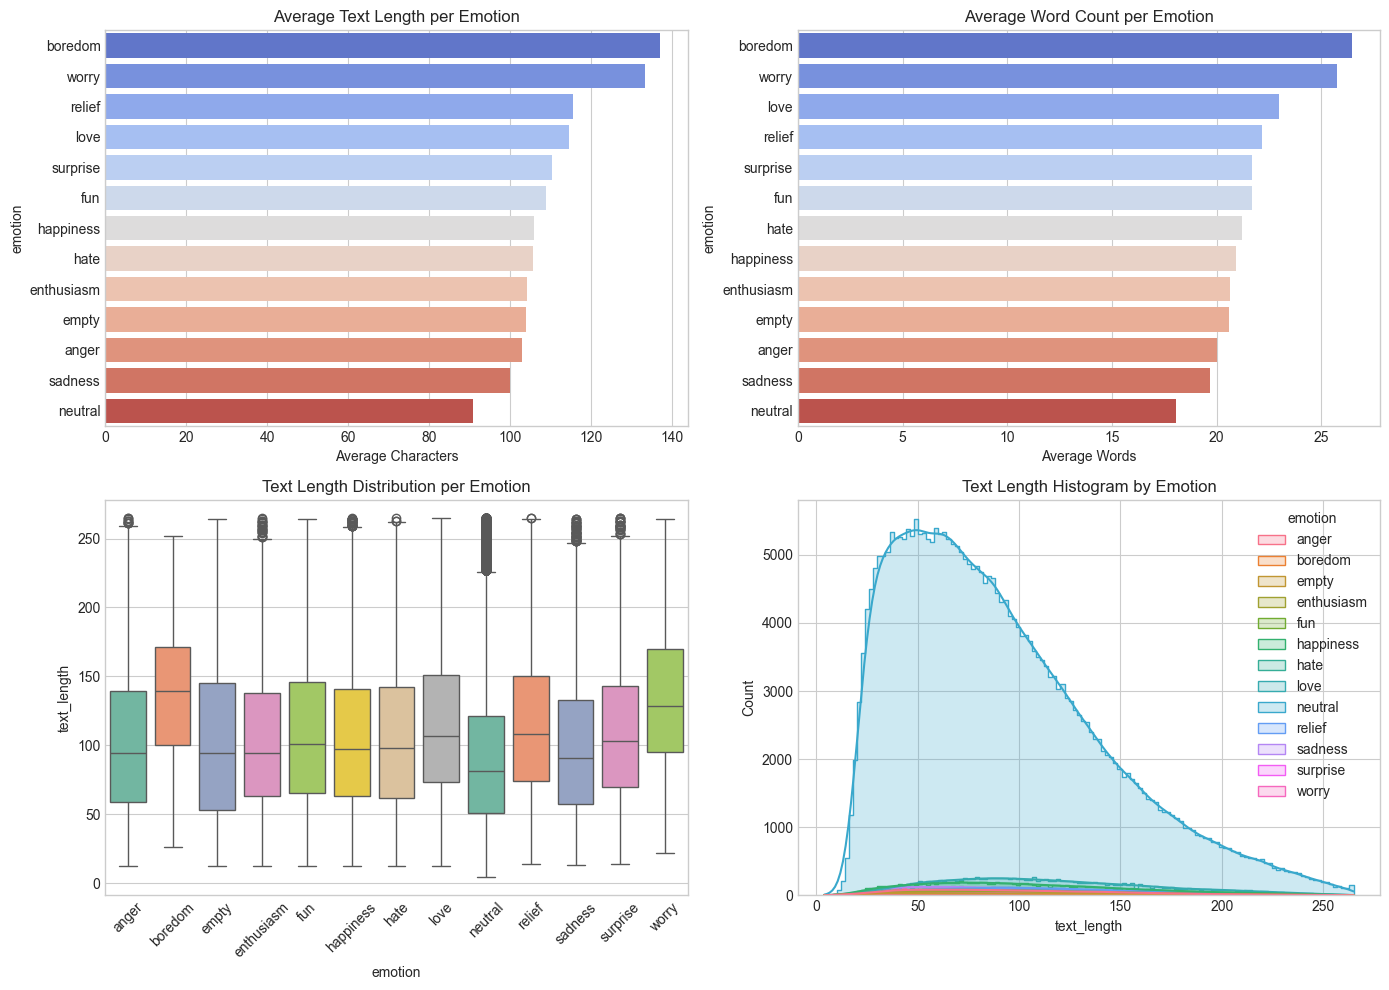

In [21]:
print("2. TEXT LENGTH & EMOTION RELATIONSHIP")

print("\nText Length Analysis (Characters):")
print(f"  Mean: {df['text_length'].mean():.2f}")
print(f"  Median: {df['text_length'].median():.2f}")
print(f"  Min: {df['text_length'].min()}")
print(f"  Max: {df['text_length'].max()}")

print("\nWord Count Analysis:")
print(f"  Mean: {df['word_count'].mean():.2f}")
print(f"  Median: {df['word_count'].median():.2f}")
print(f"  Min: {df['word_count'].min()}")
print(f"  Max: {df['word_count'].max()}")

print("\nAverage Text Length per Emotion:")
avg_length = df.groupby('emotion')['text_length'].mean().round(2).sort_values(ascending=False)
print(avg_length)

print("\nAverage Word Count per Emotion:")
avg_words = df.groupby('emotion')['word_count'].mean().round(2).sort_values(ascending=False)
print(avg_words)

print("\nEmotions with Longer/Shorter Texts:")
print(f"  Longest avg text: {avg_length.idxmax()} ({avg_length.max():.2f} chars)")
print(f"  Shortest avg text: {avg_length.idxmin()} ({avg_length.min():.2f} chars)")

print("\nDetailed Statistics per Emotion:")
text_stats = df.groupby('emotion')['text_length'].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
print(text_stats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=avg_length.values, y=avg_length.index, ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Average Text Length per Emotion')
axes[0, 0].set_xlabel('Average Characters')

sns.barplot(x=avg_words.values, y=avg_words.index, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Average Word Count per Emotion')
axes[0, 1].set_xlabel('Average Words')

sns.boxplot(data=df, x='emotion', y='text_length', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Text Length Distribution per Emotion')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.histplot(data=df, x='text_length', hue='emotion', ax=axes[1, 1], kde=True, element='step')
axes[1, 1].set_title('Text Length Histogram by Emotion')

plt.tight_layout()
plt.show()

3. WORD USAGE & VOCABULARY ANALYSIS

Top 20 Most Frequent Words in Dataset:
i          615329
feel       267122
and        222953
to         208304
the        192948
a          146790
feeling    123280
that       117116
of         115915
my          99320
in          76837
it          75626
like        66941
so          58739
for         57540
im          56005
have        54858
me          53674
but         52945
was         52257
Name: count, dtype: int64

TOP 10 WORDS PER EMOTION:

ANGER:
  i: 9483
  and: 4399
  feel: 3837
  to: 3441
  the: 2997
  angry: 2623
  feeling: 2118
  a: 2034
  that: 1824
  of: 1725

BOREDOM:
  i: 112
  to: 55
  the: 54
  boredom: 44
  a: 43
  feel: 42
  and: 39
  of: 33
  my: 32
  that: 27

EMPTY:
  i: 4401
  and: 1979
  feel: 1789
  empty: 1666
  to: 1654
  the: 1495
  feeling: 940
  of: 936
  a: 919
  that: 825

ENTHUSIASM:
  i: 7025
  to: 3678
  and: 3415
  excited: 2927
  feel: 2810
  the: 2579
  feeling: 1761
  a: 1568
  eager: 1370
  of: 1257

FUN:
 

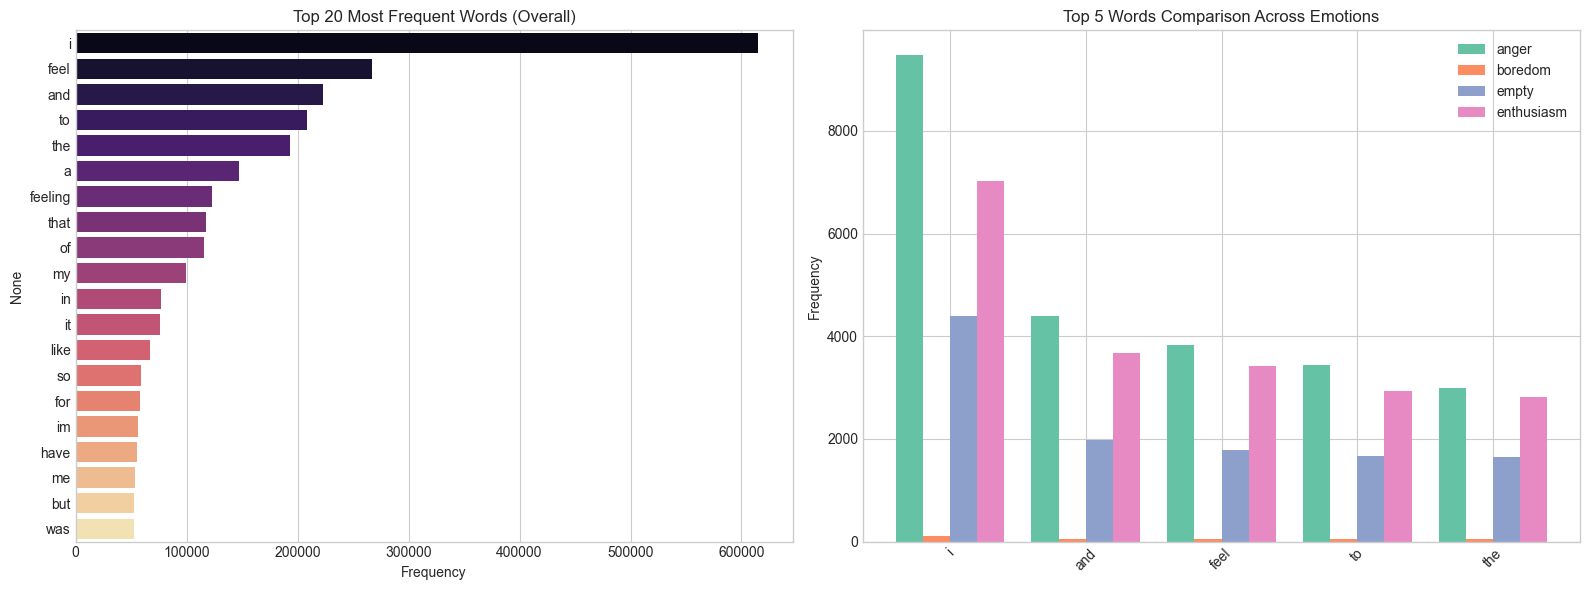

In [22]:
print("3. WORD USAGE & VOCABULARY ANALYSIS")

all_words = ' '.join(df['clean_text'].astype(str)).split()
word_freq = pd.Series(all_words).value_counts()

print("\nTop 20 Most Frequent Words in Dataset:")
print(word_freq.head(20))

print("\nTOP 10 WORDS PER EMOTION:")

emotion_top_words = {}
for emotion in df['emotion'].unique():
    emotion_texts = df[df['emotion'] == emotion]['clean_text'].astype(str)
    emotion_words = ' '.join(emotion_texts).split()
    emotion_top_words[emotion] = pd.Series(emotion_words).value_counts().head(10)
    print(f"\n{emotion.upper()}:")
    for word, count in emotion_top_words[emotion].items():
        print(f"  {word}: {count}")

print("\nEMOTION-SPECIFIC WORDS ANALYSIS:")

for emotion in df['emotion'].unique()[:4]:
    other_words = set()
    for other_emotion in df['emotion'].unique():
        if other_emotion != emotion:
            other_words.update(emotion_top_words.get(other_emotion, pd.Series()).head(20).index)
    
    current_top = set(emotion_top_words[emotion].head(20).index)
    unique_words = current_top - other_words
    print(f"\n{emotion} - Potentially unique words: {list(unique_words)[:5]}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_words = word_freq.head(20)
sns.barplot(x=top_words.values, y=top_words.index, ax=axes[0], palette='magma')
axes[0].set_title('Top 20 Most Frequent Words (Overall)')
axes[0].set_xlabel('Frequency')

emotions_to_compare = list(df['emotion'].unique())[:4]
x_pos = np.arange(5)
width = 0.2
colors = plt.cm.Set2.colors

for i, emotion in enumerate(emotions_to_compare):
    top_5 = emotion_top_words[emotion].head(5)
    axes[1].bar(x_pos + width*i, top_5.values, width, label=emotion, color=colors[i])

axes[1].set_xticks(x_pos + width*1.5)
axes[1].set_xticklabels(emotion_top_words[emotions_to_compare[0]].head(5).index, rotation=45)
axes[1].set_title('Top 5 Words Comparison Across Emotions')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

4. EMOTION-SPECIFIC LINGUISTIC PATTERNS

1. EXCLAMATION MARKS (!) ANALYSIS:
emotion
anger         0.0
boredom       0.0
empty         0.0
enthusiasm    0.0
fun           0.0
happiness     0.0
hate          0.0
love          0.0
neutral       0.0
relief        0.0
sadness       0.0
surprise      0.0
worry         0.0
Name: exclamation_count, dtype: float64

2. QUESTION MARKS (?) ANALYSIS:
emotion
anger         0.0
boredom       0.0
empty         0.0
enthusiasm    0.0
fun           0.0
happiness     0.0
hate          0.0
love          0.0
neutral       0.0
relief        0.0
sadness       0.0
surprise      0.0
worry         0.0
Name: question_count, dtype: float64

3. UPPERCASE CHARACTERS ANALYSIS:
emotion
anger         0.0
boredom       0.0
empty         0.0
enthusiasm    0.0
fun           0.0
happiness     0.0
hate          0.0
love          0.0
neutral       0.0
relief        0.0
sadness       0.0
surprise      0.0
worry         0.0
Name: uppercase_count, dtype: float64

4. POSITIVE WO

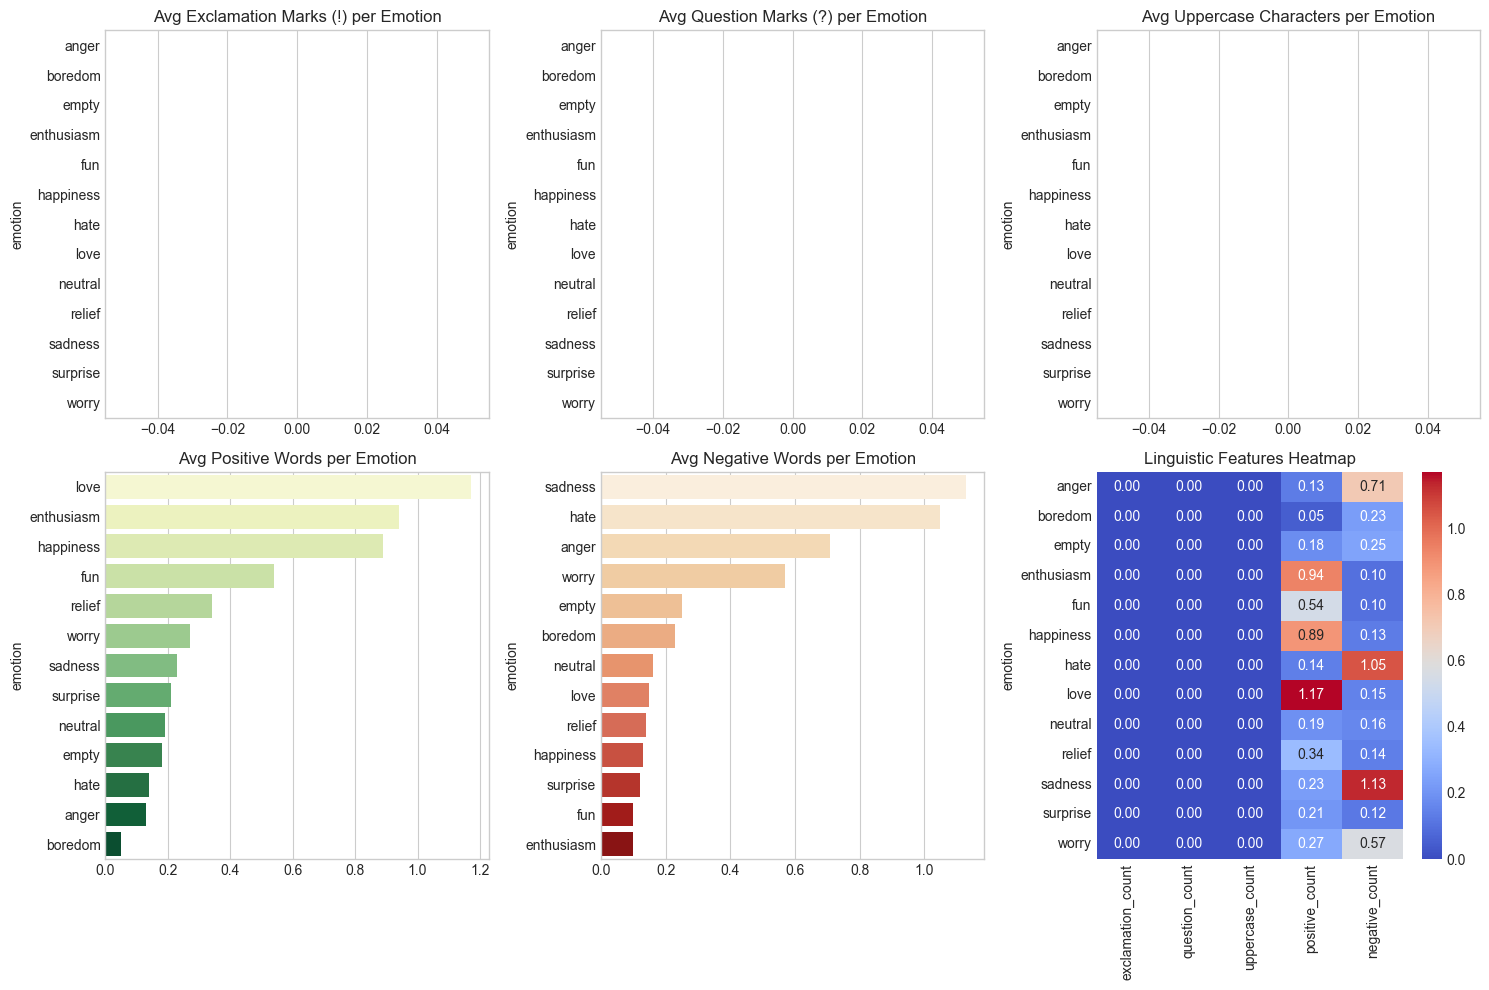

In [23]:
print("4. EMOTION-SPECIFIC LINGUISTIC PATTERNS")

positive_words = [
    'happy','happiness','happier','happiest',
    'love','loved','lovely','loving',
    'good','better','best',
    'great','greater','greatest',
    'excellent','amazing','awesome','fantastic','wonderful','brilliant',
    'beautiful','pretty','attractive',
    'nice','kind','sweet','friendly',
    'excited','exciting','joy','joyful','delight','delighted',
    'pleased','pleasant','positive','optimistic',
    'perfect','perfectly',
    'enjoy','enjoyed','enjoying',
    'success','successful','win','winning','won',
    'calm','peaceful','relaxed','relaxing',
    'confident','proud','grateful','thankful',
    'incredible','outstanding','superb','terrific'
]
negative_words = [
    'sad','sadness','sadder',
    'bad','worse','worst',
    'hate','hated','hateful',
    'angry','anger','furious','mad',
    'fear','afraid','scared','terrified',
    'terrible','awful','horrible','disgusting',
    'upset','upsetting',
    'disappointed','disappointing',
    'hurt','hurting','pain','painful',
    'depressed','depressing',
    'anxious','anxiety','stressed','stressful',
    'lonely','alone',
    'cry','crying','cried',
    'fail','failed','failure',
    'problem','problems',
    'annoyed','annoying','frustrated','frustrating',
    'guilty','shame','ashamed',
    'jealous','regret','regretful',
    'tired','exhausted'
]

def count_positive(text):
    return sum(1 for word in str(text).lower().split() if word in positive_words)

def count_negative(text):
    return sum(1 for word in str(text).lower().split() if word in negative_words)

df['positive_count'] = df['text'].apply(count_positive)
df['negative_count'] = df['text'].apply(count_negative)

print("\n1. EXCLAMATION MARKS (!) ANALYSIS:")
excl_by_emotion = df.groupby('emotion')['exclamation_count'].mean().round(2).sort_values(ascending=False)
print(excl_by_emotion)

print("\n2. QUESTION MARKS (?) ANALYSIS:")
quest_by_emotion = df.groupby('emotion')['question_count'].mean().round(2).sort_values(ascending=False)
print(quest_by_emotion)

print("\n3. UPPERCASE CHARACTERS ANALYSIS:")
upper_by_emotion = df.groupby('emotion')['uppercase_count'].mean().round(2).sort_values(ascending=False)
print(upper_by_emotion)

print("\n4. POSITIVE WORDS USAGE:")
pos_by_emotion = df.groupby('emotion')['positive_count'].mean().round(2).sort_values(ascending=False)
print(pos_by_emotion)

print("\n5. NEGATIVE WORDS USAGE:")
neg_by_emotion = df.groupby('emotion')['negative_count'].mean().round(2).sort_values(ascending=False)
print(neg_by_emotion)

print("\nLINGUISTIC FEATURES COMPARISON ACROSS EMOTIONS:")
linguistic_comparison = df.groupby('emotion').agg({
    'exclamation_count': 'mean',
    'question_count': 'mean',
    'uppercase_count': 'mean',
    'positive_count': 'mean',
    'negative_count': 'mean'
}).round(2)
print(linguistic_comparison)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.barplot(x=excl_by_emotion.values, y=excl_by_emotion.index, ax=axes[0, 0], palette='Reds')
axes[0, 0].set_title('Avg Exclamation Marks (!) per Emotion')

sns.barplot(x=quest_by_emotion.values, y=quest_by_emotion.index, ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Avg Question Marks (?) per Emotion')

sns.barplot(x=upper_by_emotion.values, y=upper_by_emotion.index, ax=axes[0, 2], palette='Greens')
axes[0, 2].set_title('Avg Uppercase Characters per Emotion')

sns.barplot(x=pos_by_emotion.values, y=pos_by_emotion.index, ax=axes[1, 0], palette='YlGn')
axes[1, 0].set_title('Avg Positive Words per Emotion')

sns.barplot(x=neg_by_emotion.values, y=neg_by_emotion.index, ax=axes[1, 1], palette='OrRd')
axes[1, 1].set_title('Avg Negative Words per Emotion')

sns.heatmap(linguistic_comparison, annot=True, cmap='coolwarm', ax=axes[1, 2], fmt='.2f')
axes[1, 2].set_title('Linguistic Features Heatmap')

plt.tight_layout()
plt.show()

5. STOPWORDS & NOISE ANALYSIS

1. STOPWORD STATISTICS:
   Total words in dataset: 7189548
   Stopwords count: 3939965
   Stopwords percentage: 54.80%
   Non-stopwords: 3249583

2. TOP 10 WORDS BEFORE STOPWORD REMOVAL:
i          615329
feel       267122
and        222953
to         208304
the        192948
a          146790
feeling    123280
that       117116
of         115915
my          99320
Name: count, dtype: int64

3. TOP 10 WORDS AFTER STOPWORD REMOVAL:
feel         267122
feeling      123280
time          19176
little        17608
people        16199
want          14644
think         14226
life          12426
something     11977
bit           11953
Name: count, dtype: int64

4. EFFECT ON EMOTION-SPECIFIC PATTERNS:

ANGER:
  Before: ['i', 'and', 'feel', 'to', 'the']
  After:  ['feel', 'angry', 'feeling', 'discouraged', 'outraged']

BOREDOM:
  Before: ['i', 'to', 'the', 'boredom', 'a']
  After:  ['boredom', 'feel', 'feeling', 'monotony', 'chest']

EMPTY:
  Before: ['i', 'and', 'f

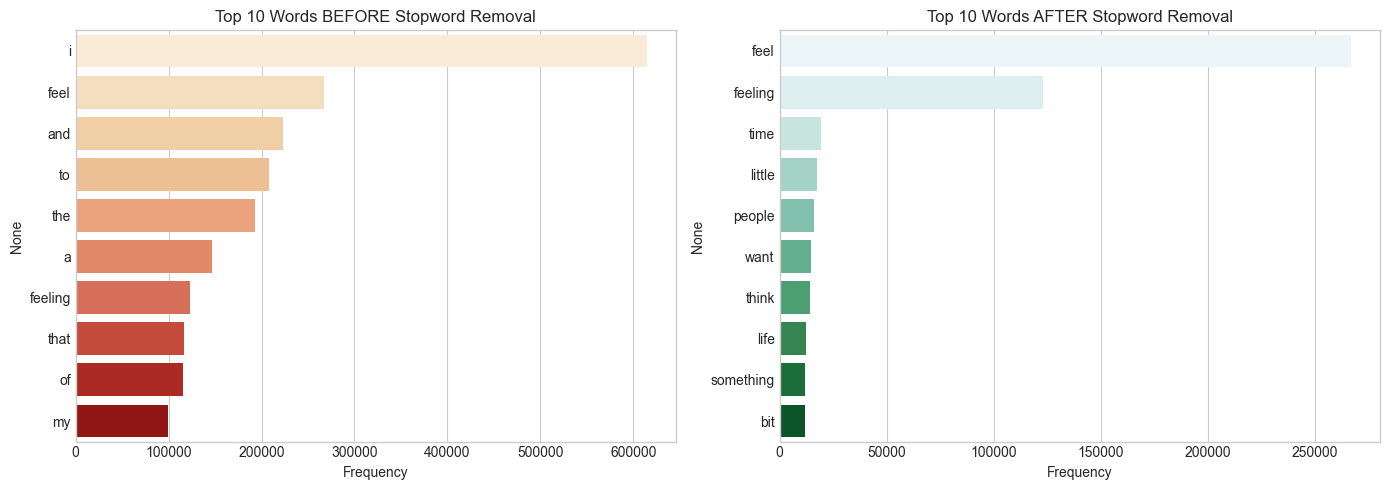

In [24]:
print("5. STOPWORDS & NOISE ANALYSIS")

stopwords = ["i", "me", "my", "myself", "we",  "like", "really", "know", "get", "would",
    "one", "also", "even", "still", "much", "could", "us", "im", "ive", "dont" "our", 
    "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", 
    "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", 
    "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", 
    "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", 
    "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", 
    "between", "into", "through", "during", "before", "after", "above", "below", 
    "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", 
    "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", 
    "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", 
    "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"]

all_words = ' '.join(df['clean_text'].astype(str)).split()
total_words = len(all_words)
stopword_count = sum(1 for w in all_words if w in stopwords)

print("\n1. STOPWORD STATISTICS:")
print(f"   Total words in dataset: {total_words}")
print(f"   Stopwords count: {stopword_count}")
print(f"   Stopwords percentage: {(stopword_count/total_words)*100:.2f}%")
print(f"   Non-stopwords: {total_words - stopword_count}")

print("\n2. TOP 10 WORDS BEFORE STOPWORD REMOVAL:")
word_freq_before = pd.Series(all_words).value_counts().head(10)
print(word_freq_before)

filtered_words = [w for w in all_words if w not in stopwords and len(w) > 2]
print("\n3. TOP 10 WORDS AFTER STOPWORD REMOVAL:")
word_freq_after = pd.Series(filtered_words).value_counts().head(10)
print(word_freq_after)

print("\n4. EFFECT ON EMOTION-SPECIFIC PATTERNS:")

for emotion in df['emotion'].unique()[:3]:
    emotion_texts = df[df['emotion'] == emotion]['clean_text'].astype(str)
    emotion_words = ' '.join(emotion_texts).split()
    
    before_top = pd.Series(emotion_words).value_counts().head(5)
    filtered_emotion = [w for w in emotion_words if w not in stopwords and len(w) > 2]
    after_top = pd.Series(filtered_emotion).value_counts().head(5)
    
    print(f"\n{emotion.upper()}:")
    print(f"  Before: {list(before_top.index)}")
    print(f"  After:  {list(after_top.index)}")

print("\n5. CONCLUSION:")
print("""
- Stopwords make up a significant portion of the text
- After removal, emotion-related words become more visible
- Recommendation: Remove stopwords for better feature extraction
- Note: Some stopwords like 'feel' may be useful for emotion detection
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=word_freq_before.values, y=word_freq_before.index, ax=axes[0], palette='OrRd')
axes[0].set_title('Top 10 Words BEFORE Stopword Removal')
axes[0].set_xlabel('Frequency')

sns.barplot(x=word_freq_after.values, y=word_freq_after.index, ax=axes[1], palette='BuGn')
axes[1].set_title('Top 10 Words AFTER Stopword Removal')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

6. EMOTION SIMILARITY & OVERLAP

1. WORD OVERLAP BETWEEN EMOTION PAIRS:
anger <-> boredom: 16 common words
anger <-> empty: 24 common words
anger <-> enthusiasm: 28 common words
anger <-> fun: 28 common words
anger <-> happiness: 30 common words
anger <-> hate: 29 common words
anger <-> love: 29 common words
anger <-> neutral: 33 common words
anger <-> relief: 32 common words
anger <-> sadness: 32 common words
anger <-> surprise: 30 common words
anger <-> worry: 27 common words
boredom <-> empty: 12 common words
boredom <-> enthusiasm: 15 common words
boredom <-> fun: 15 common words
boredom <-> happiness: 14 common words
boredom <-> hate: 15 common words
boredom <-> love: 14 common words
boredom <-> neutral: 17 common words
boredom <-> relief: 16 common words
boredom <-> sadness: 11 common words
boredom <-> surprise: 14 common words
boredom <-> worry: 13 common words
empty <-> enthusiasm: 25 common words
empty <-> fun: 26 common words
empty <-> happiness: 26 common words
empty <-> hat

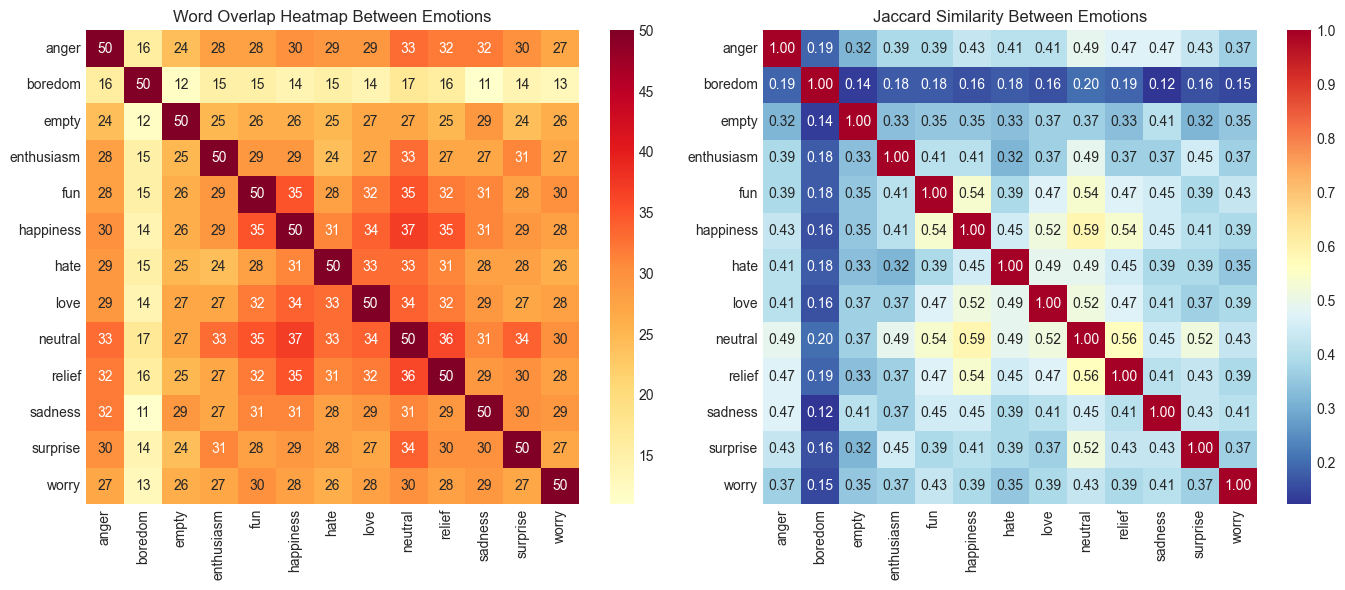

In [25]:
print("6. EMOTION SIMILARITY & OVERLAP")

stopwords_set = set(["i", "me", "my", "myself", "we",  "like", "really", "know", "get", "would",
    "one", "also", "even", "still", "much", "could", "us", "im", "ive", "dont" "our", 
    "ours", "ourselves", "you", "your", "yours", "yourself", "yourselves", "he", "him", "his", 
    "himself", "she", "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these", "those", 
    "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", 
    "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", 
    "as", "until", "while", "of", "at", "by", "for", "with", "about", "against", 
    "between", "into", "through", "during", "before", "after", "above", "below", 
    "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again", 
    "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", 
    "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", 
    "only", "own", "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"])

emotion_vocab = {}
for emotion in df['emotion'].unique():
    texts = df[df['emotion'] == emotion]['clean_text'].astype(str)
    words = ' '.join(texts).split()
    filtered = [w for w in words if w not in stopwords_set and len(w) > 2]
    emotion_vocab[emotion] = set(pd.Series(filtered).value_counts().head(50).index)

print("\n1. WORD OVERLAP BETWEEN EMOTION PAIRS:")
emotions = list(emotion_vocab.keys())
overlap_matrix = np.zeros((len(emotions), len(emotions)))

for i in range(len(emotions)):
    for j in range(len(emotions)):
        e1, e2 = emotions[i], emotions[j]
        overlap = len(emotion_vocab[e1].intersection(emotion_vocab[e2]))
        overlap_matrix[i, j] = overlap

for i in range(len(emotions)):
    for j in range(i+1, len(emotions)):
        e1, e2 = emotions[i], emotions[j]
        overlap = emotion_vocab[e1].intersection(emotion_vocab[e2])
        print(f"{e1} <-> {e2}: {len(overlap)} common words")

print("\n2. CONFUSION-PRONE EMOTION PAIRS:")
overlap_df = pd.DataFrame(overlap_matrix, index=emotions, columns=emotions)
for i in range(len(emotions)):
    for j in range(i+1, len(emotions)):
        if overlap_matrix[i, j] > 30:
            print(f"  {emotions[i]} vs {emotions[j]}: High similarity ({int(overlap_matrix[i, j])} words)")
            common = list(emotion_vocab[emotions[i]].intersection(emotion_vocab[emotions[j]]))[:5]
            print(f"    Common words: {common}")

print("\n3. WORDS COMMON TO ALL EMOTIONS:")
if emotion_vocab:
    common_all = set.intersection(*emotion_vocab.values())
    print(f"Number of common words: {len(common_all)}")
    print(f"Words: {list(common_all)[:15]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(overlap_df, annot=True, cmap='YlOrRd', fmt='.0f', ax=axes[0])
axes[0].set_title('Word Overlap Heatmap Between Emotions')

jaccard_matrix = np.zeros((len(emotions), len(emotions)))
for i in range(len(emotions)):
    for j in range(len(emotions)):
        e1, e2 = emotions[i], emotions[j]
        intersection = len(emotion_vocab[e1].intersection(emotion_vocab[e2]))
        union = len(emotion_vocab[e1].union(emotion_vocab[e2]))
        jaccard_matrix[i, j] = intersection / union if union > 0 else 0

jaccard_df = pd.DataFrame(jaccard_matrix, index=emotions, columns=emotions)
sns.heatmap(jaccard_df, annot=True, cmap='RdYlBu_r', fmt='.2f', ax=axes[1])
axes[1].set_title('Jaccard Similarity Between Emotions')

plt.tight_layout()
plt.show()

7. DATA QUALITY & CLEANING INSIGHTS

1. DUPLICATE TEXT ANALYSIS:
   Duplicate texts: 0
   Unique texts: 384140

2. EMPTY/NULL VALUE ANALYSIS:
text                 0
emotion              0
emotion_encoded      0
clean_text           0
text_length          0
word_count           0
avg_word_length      0
exclamation_count    0
question_count       0
uppercase_count      0
positive_count       0
negative_count       0
dtype: int64

   Empty texts (whitespace only): 0

3. EMOTION CONSISTENCY (Same text -> Different emotions):
   Texts with multiple emotion labels: 0

4. NOISY/AMBIGUOUS SAMPLE DETECTION:
   Very short texts (< 10 chars): 30
   Very long texts (> 500 chars): 0
   Texts with < 2 words after cleaning: 7

5. DATA QUALITY SUMMARY:
   Total Records: 384140
   Duplicate Texts: 0
   Null Values: 0
   Empty Texts: 0
   Inconsistent Labels: 0
   Very Short Texts: 30
   Quality Score: 100.0


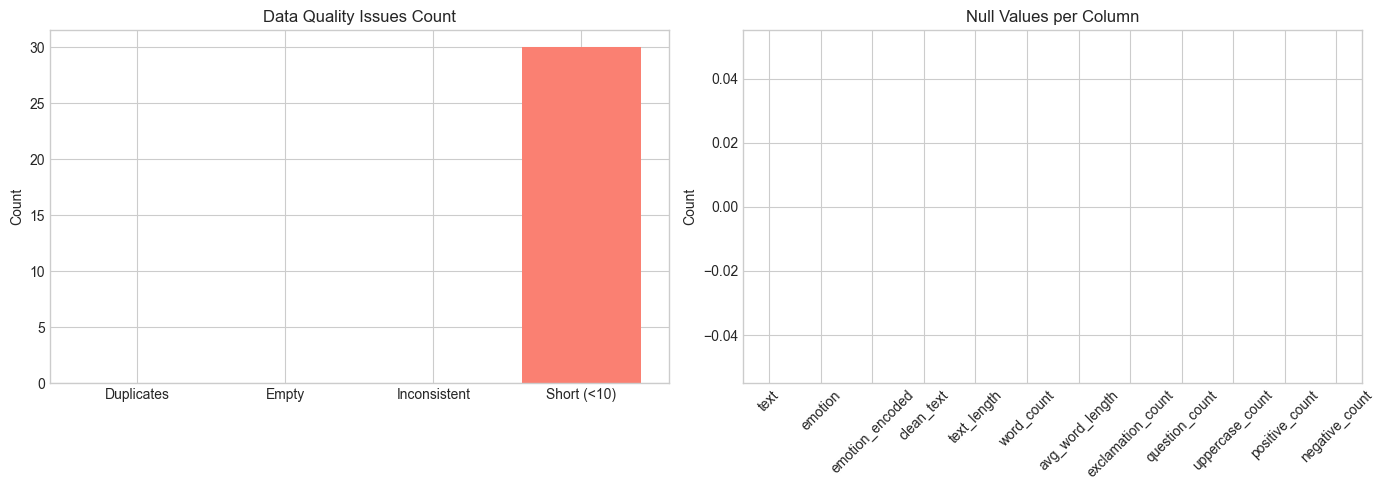

In [26]:
print("7. DATA QUALITY & CLEANING INSIGHTS")

print("\n1. DUPLICATE TEXT ANALYSIS:")
duplicate_texts = df['text'].duplicated().sum()
print(f"   Duplicate texts: {duplicate_texts}")
print(f"   Unique texts: {df['text'].nunique()}")

print("\n2. EMPTY/NULL VALUE ANALYSIS:")
null_counts = df.isnull().sum()
print(null_counts)

empty_texts = df[df['text'].str.strip() == ''].shape[0]
print(f"\n   Empty texts (whitespace only): {empty_texts}")

print("\n3. EMOTION CONSISTENCY (Same text -> Different emotions):")
text_emotion_map = df.groupby('text')['emotion'].nunique()
inconsistent = text_emotion_map[text_emotion_map > 1]
print(f"   Texts with multiple emotion labels: {len(inconsistent)}")

if len(inconsistent) > 0:
    print("\n   Examples of inconsistent labeling:")
    for text in inconsistent.head(3).index:
        emotions = df[df['text'] == text]['emotion'].unique()
        print(f"   Text: '{text[:50]}...'")
        print(f"   Labels: {list(emotions)}\n")

print("\n4. NOISY/AMBIGUOUS SAMPLE DETECTION:")
short_texts = df[df['text_length'] < 10]
print(f"   Very short texts (< 10 chars): {len(short_texts)}")

long_texts = df[df['text_length'] > 500]
print(f"   Very long texts (> 500 chars): {len(long_texts)}")

very_short_clean = df[df['clean_text'].str.split().str.len() < 2]
print(f"   Texts with < 2 words after cleaning: {len(very_short_clean)}")

print("\n5. DATA QUALITY SUMMARY:")
quality_metrics = {
    'Total Records': len(df),
    'Duplicate Texts': duplicate_texts,
    'Null Values': df.isnull().sum().sum(),
    'Empty Texts': empty_texts,
    'Inconsistent Labels': len(inconsistent),
    'Very Short Texts': len(short_texts),
    'Quality Score': round((1 - (duplicate_texts + empty_texts + len(inconsistent)) / len(df)) * 100, 2)
}
for metric, value in quality_metrics.items():
    print(f"   {metric}: {value}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_issues = {'Duplicates': duplicate_texts, 'Empty': empty_texts, 
                  'Inconsistent': len(inconsistent), 'Short (<10)': len(short_texts)}
colors = ['salmon' if v > 0 else 'lightgreen' for v in quality_issues.values()]
axes[0].bar(quality_issues.keys(), quality_issues.values(), color=colors)
axes[0].set_title('Data Quality Issues Count')
axes[0].set_ylabel('Count')

null_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Null Values per Column')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Feature Engineering

In [27]:
print("FEATURE ENGINEERING FOR MODEL TRAINING")

print("\n1. TF-IDF VECTORIZATION:")

tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['clean_text'].astype(str))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print(f"   TF-IDF features shape: {tfidf_df.shape}")
print(f"   Number of features: {len(tfidf.get_feature_names_out())}")
print(f"\n   Top 20 TF-IDF features:")
print(f"   {list(tfidf.get_feature_names_out()[:20])}")

print("\n2. BAG OF WORDS (Count Vectorizer):")

count_vec = CountVectorizer(max_features=500, stop_words='english')
bow_matrix = count_vec.fit_transform(df['clean_text'].astype(str))
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=count_vec.get_feature_names_out())

print(f"   BoW features shape: {bow_df.shape}")

print("\n3. HANDCRAFTED FEATURES:")

df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['avg_word_len'] = df['char_count'] / df['word_count']
df['unique_word_count'] = df['text'].apply(lambda x: len(set(str(x).lower().split())))
df['unique_word_ratio'] = df['unique_word_count'] / df['word_count']
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count('\?')
df['uppercase_ratio'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)))
df['digit_count'] = df['text'].str.count(r'\d')

handcrafted_features = ['char_count', 'word_count', 'avg_word_len', 'unique_word_count',
                        'unique_word_ratio', 'exclamation_count', 'question_count',
                        'uppercase_ratio', 'digit_count', 'positive_count', 'negative_count']

print(f"   Handcrafted features: {handcrafted_features}")

print("\n4. COMBINED FEATURE MATRIX:")

numeric_df = df[handcrafted_features].copy()

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=handcrafted_features)

feature_matrix = pd.concat([tfidf_df.reset_index(drop=True), 
                            numeric_scaled_df.reset_index(drop=True)], axis=1)

print(f"   Final feature matrix shape: {feature_matrix.shape}")
print(f"   TF-IDF features: {tfidf_df.shape[1]}")
print(f"   Numeric features: {len(handcrafted_features)}")
print(f"   Total features: {feature_matrix.shape[1]}")

print("\n5. FEATURE MATRIX SAMPLE (first 5 rows, first 10 columns):")
print(feature_matrix.iloc[:5, :10])

print("\n6. FEATURE STATISTICS:")
print(feature_matrix.describe().iloc[:, :5])

FEATURE ENGINEERING FOR MODEL TRAINING

1. TF-IDF VECTORIZATION:
   TF-IDF features shape: (384140, 1000)
   Number of features: 1000

   Top 20 TF-IDF features:
   ['ability', 'able', 'absolutely', 'abused', 'acceptable', 'accepted', 'aching', 'act', 'actually', 'actually feel', 'add', 'admit', 'adventurous', 'afraid', 'age', 'agitated', 'ago', 'air', 'amazed', 'amazing']

2. BAG OF WORDS (Count Vectorizer):
   BoW features shape: (384140, 500)

3. HANDCRAFTED FEATURES:
   Handcrafted features: ['char_count', 'word_count', 'avg_word_len', 'unique_word_count', 'unique_word_ratio', 'exclamation_count', 'question_count', 'uppercase_ratio', 'digit_count', 'positive_count', 'negative_count']

4. COMBINED FEATURE MATRIX:
   Final feature matrix shape: (384140, 1011)
   TF-IDF features: 1000
   Numeric features: 11
   Total features: 1011

5. FEATURE MATRIX SAMPLE (first 5 rows, first 10 columns):
   ability  able  absolutely  abused  acceptable  accepted  aching  act  \
0      0.0   0.0    

## Feature Reduction
- 1.h.i - Correlation Analysis (Remove highly correlated input features)
- 1.h.ii - PCA for Dimensionality Reduction

CORRELATION ANALYSIS - INPUT FEATURES ONLY (Not Target)

1. CORRELATION MATRIX (Numeric Features):
                   char_count  word_count  avg_word_len  unique_word_count  \
char_count               1.00        0.98          0.12               0.98   
word_count               0.98        1.00         -0.04               0.98   
avg_word_len             0.12       -0.04          1.00               0.00   
unique_word_count        0.98        0.98          0.00               1.00   
unique_word_ratio       -0.55       -0.60          0.24              -0.47   
exclamation_count         NaN         NaN           NaN                NaN   
question_count            NaN         NaN           NaN                NaN   
uppercase_ratio           NaN         NaN           NaN                NaN   
digit_count               NaN         NaN           NaN                NaN   
positive_count           0.18        0.19          0.00               0.18   
negative_count           0.10        0.10  

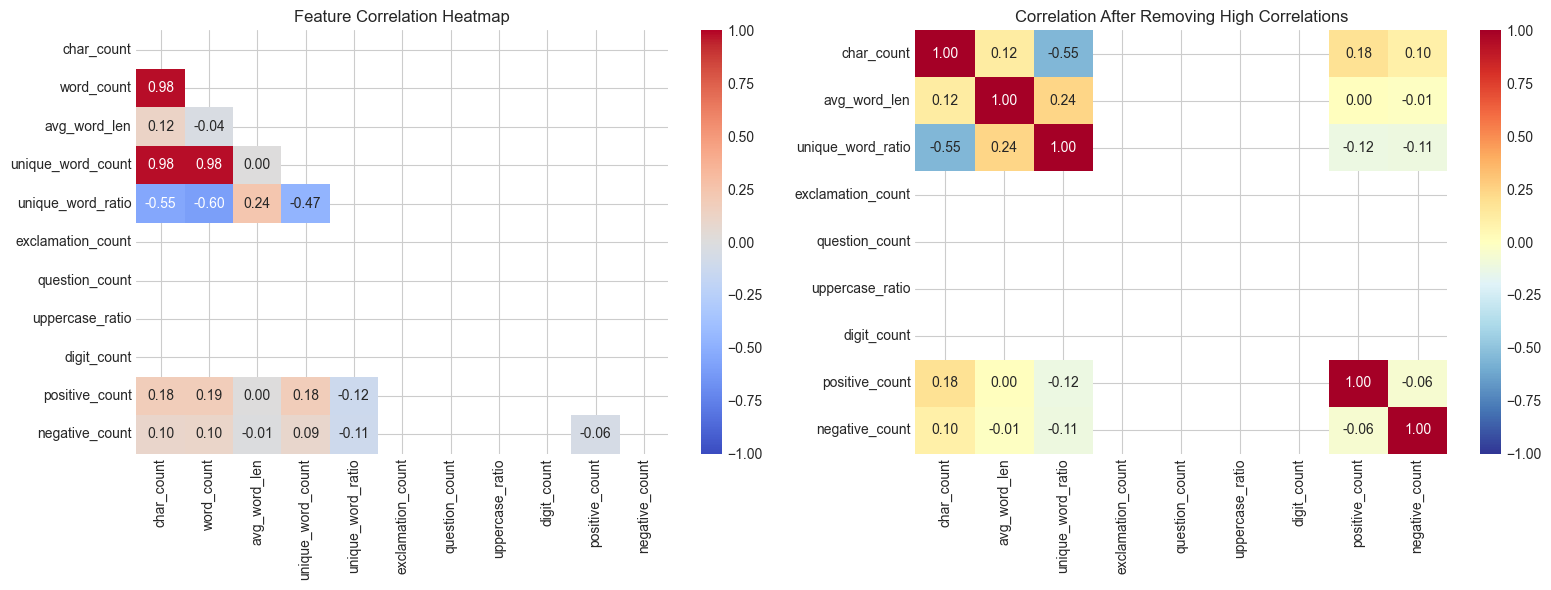

In [28]:
print("CORRELATION ANALYSIS - INPUT FEATURES ONLY (Not Target)")

numeric_features = ['char_count', 'word_count', 'avg_word_len', 'unique_word_count',
                    'unique_word_ratio', 'exclamation_count', 'question_count',
                    'uppercase_ratio', 'digit_count', 'positive_count', 'negative_count']

correlation_matrix = df[numeric_features].corr()

print("\n1. CORRELATION MATRIX (Numeric Features):")
print(correlation_matrix.round(2))

print("\n2. HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8):")

high_corr_pairs = []
threshold = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feature1, feature2, corr_value))
            print(f"   {feature1} <-> {feature2}: {corr_value:.3f}")

if not high_corr_pairs:
    print("   No highly correlated pairs found (threshold > 0.8)")

print("\n3. FEATURE REMOVAL DECISION:")

features_to_remove = set()
for f1, f2, corr in high_corr_pairs:
    if f2 not in features_to_remove:
        features_to_remove.add(f2)
        print(f"   Removing '{f2}' (correlated with '{f1}', r={corr:.3f})")

if features_to_remove:
    selected_features = [f for f in numeric_features if f not in features_to_remove]
    print(f"\n   Original features: {len(numeric_features)}")
    print(f"   Features removed: {len(features_to_remove)}")
    print(f"   Remaining features: {len(selected_features)}")
    print(f"   Selected features: {selected_features}")
else:
    selected_features = numeric_features
    print("   No features removed - all correlations below threshold")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, ax=axes[0], fmt='.2f', vmin=-1, vmax=1)
axes[0].set_title('Feature Correlation Heatmap')

correlation_filtered = df[selected_features].corr()
sns.heatmap(correlation_filtered, annot=True, cmap='RdYlBu_r', 
            center=0, ax=axes[1], fmt='.2f', vmin=-1, vmax=1)
axes[1].set_title('Correlation After Removing High Correlations')

plt.tight_layout()
plt.show()

PCA - PRINCIPAL COMPONENT ANALYSIS

1. ORIGINAL TF-IDF FEATURE DIMENSIONS: (384140, 1000)

2. APPLYING PCA TO TF-IDF FEATURES:
   Components needed for 50% variance: 256
   Components needed for 75% variance: 495
   Components needed for 90% variance: 732
   Components needed for 95% variance: 839

3. PCA TRANSFORMATION RESULTS:
   Original dimensions: 1000
   Reduced dimensions: 839
   Dimensionality reduction: 16.10%
   Variance retained: 95.01%

4. TOP 10 PRINCIPAL COMPONENT VARIANCE:
   PC1: 1.83%
   PC2: 1.34%
   PC3: 0.92%
   PC4: 0.64%
   PC5: 0.60%
   PC6: 0.57%
   PC7: 0.55%
   PC8: 0.49%
   PC9: 0.47%
   PC10: 0.46%


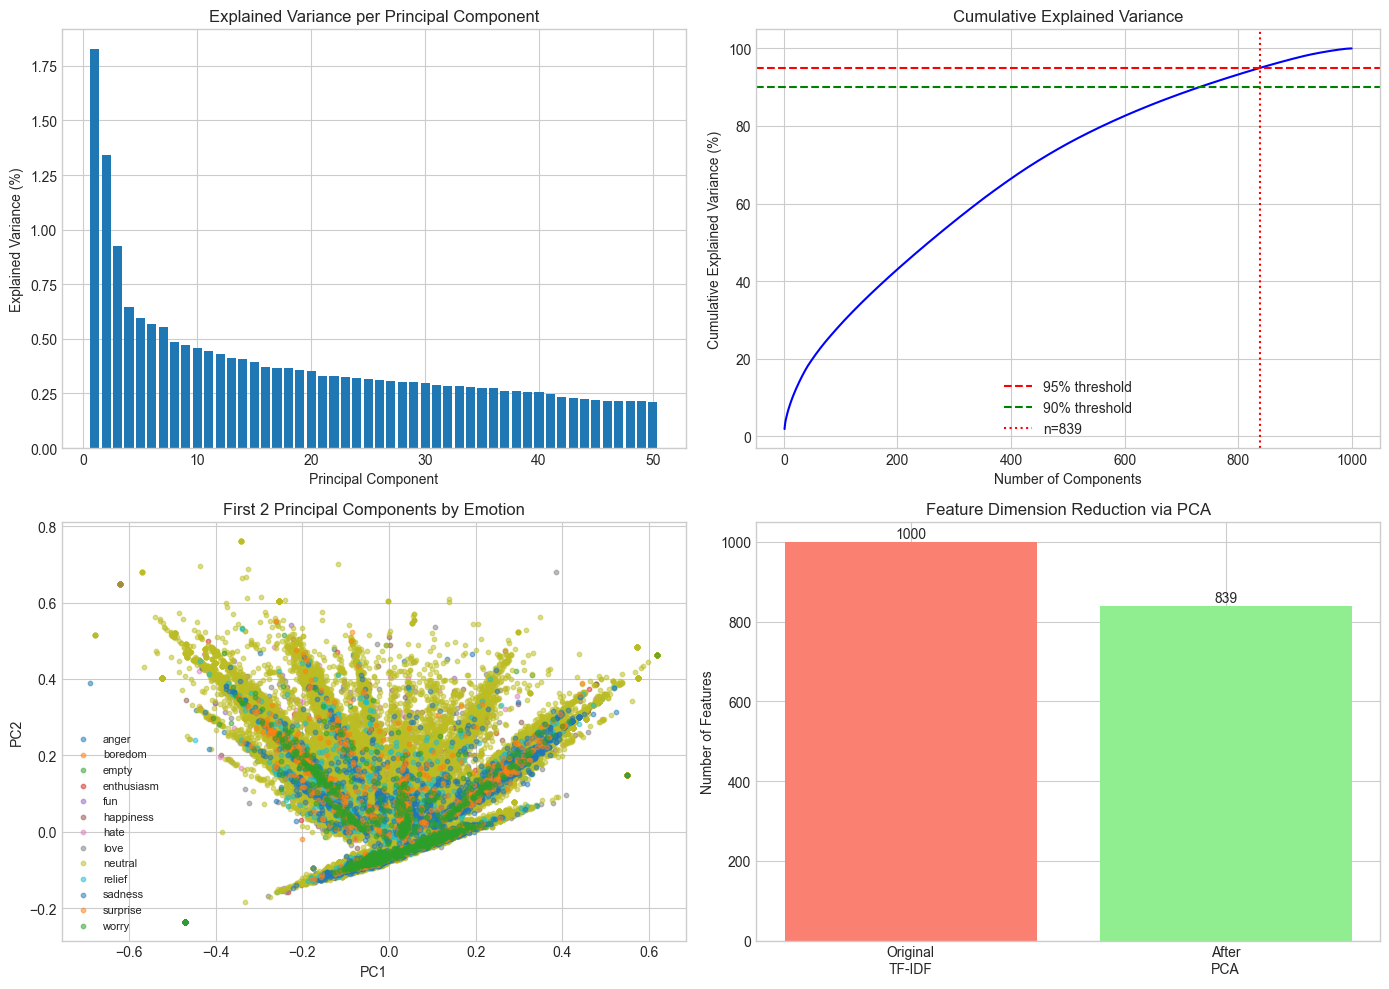

In [29]:
print("PCA - PRINCIPAL COMPONENT ANALYSIS")

X_tfidf = tfidf_matrix.toarray()

print(f"\n1. ORIGINAL TF-IDF FEATURE DIMENSIONS: {X_tfidf.shape}")

print("\n2. APPLYING PCA TO TF-IDF FEATURES:")

pca_full = PCA()
pca_full.fit(X_tfidf)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(f"   Components needed for 50% variance: {np.argmax(cumulative_variance >= 0.50) + 1}")
print(f"   Components needed for 75% variance: {np.argmax(cumulative_variance >= 0.75) + 1}")
print(f"   Components needed for 90% variance: {np.argmax(cumulative_variance >= 0.90) + 1}")
print(f"   Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")

n_components = np.argmax(cumulative_variance >= 0.95) + 1
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_tfidf)

print(f"\n3. PCA TRANSFORMATION RESULTS:")
print(f"   Original dimensions: {X_tfidf.shape[1]}")
print(f"   Reduced dimensions: {X_pca.shape[1]}")
print(f"   Dimensionality reduction: {((X_tfidf.shape[1] - X_pca.shape[1]) / X_tfidf.shape[1]) * 100:.2f}%")
print(f"   Variance retained: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

print(f"\n4. TOP 10 PRINCIPAL COMPONENT VARIANCE:")
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"   PC{i+1}: {var*100:.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(range(1, min(51, len(pca.explained_variance_ratio_)+1)), 
               pca.explained_variance_ratio_[:50] * 100)
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance (%)')
axes[0, 0].set_title('Explained Variance per Principal Component')

axes[0, 1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, 'b-')
axes[0, 1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[0, 1].axhline(y=90, color='g', linestyle='--', label='90% threshold')
axes[0, 1].axvline(x=n_components, color='r', linestyle=':', label=f'n={n_components}')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance (%)')
axes[0, 1].set_title('Cumulative Explained Variance')
axes[0, 1].legend()

pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['emotion'] = df['emotion'].values

for emotion in pca_df['emotion'].unique():
    mask = pca_df['emotion'] == emotion
    axes[1, 0].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], 
                       label=emotion, alpha=0.5, s=10)
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('First 2 Principal Components by Emotion')
axes[1, 0].legend(fontsize=8)

dimensions = ['Original\nTF-IDF', 'After\nPCA']
values = [X_tfidf.shape[1], X_pca.shape[1]]
colors = ['salmon', 'lightgreen']
axes[1, 1].bar(dimensions, values, color=colors)
axes[1, 1].set_ylabel('Number of Features')
axes[1, 1].set_title('Feature Dimension Reduction via PCA')
for i, v in enumerate(values):
    axes[1, 1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

In [30]:
print("FINAL DATASET READY FOR MODEL TRAINING")

X_numeric = scaler.fit_transform(df[selected_features])
X_final = np.hstack([X_pca, X_numeric])

y = df['emotion_encoded'].values

print("\n1. FINAL FEATURE MATRIX:")
print(f"   PCA features: {X_pca.shape[1]}")
print(f"   Numeric features: {len(selected_features)}")
print(f"   Total features: {X_final.shape[1]}")
print(f"   Total samples: {X_final.shape[0]}")

print("\n2. TARGET VARIABLE:")
print(f"   Classes: {len(np.unique(y))}")
print(f"   Class distribution:")
for emotion, code in zip(le.classes_, le.transform(le.classes_)):
    count = np.sum(y == code)
    print(f"      {emotion} ({code}): {count} samples ({count/len(y)*100:.2f}%)")

print("\n3. PREPROCESSING SUMMARY:")
print("""
   a. Missing Data: Handled (dropped/filled)
   b. Duplicates: Removed
   c. Encoding: Label encoding for target (emotion)
   d. Basic EDA: Descriptive statistics computed
   e. Outliers: Removed using Z-Score method
   f. Assigned EDA: 7 analyses completed
   g. Feature Engineering: TF-IDF + Handcrafted features
   h. Feature Reduction: Correlation + PCA applied
""")

print("\n4. READY FOR MODEL TRAINING:")
print(f"   X shape: {X_final.shape}")
print(f"   y shape: {y.shape}")
print(f"   Next step: Train-test split and model building")

final_data_info = {
    'X_shape': X_final.shape,
    'y_shape': y.shape,
    'n_classes': len(np.unique(y)),
    'class_names': list(le.classes_),
    'features_pca': X_pca.shape[1],
    'features_numeric': len(selected_features)
}

print("\n5. DATA INFO SAVED:")
for key, value in final_data_info.items():
    print(f"   {key}: {value}")

FINAL DATASET READY FOR MODEL TRAINING

1. FINAL FEATURE MATRIX:
   PCA features: 839
   Numeric features: 9
   Total features: 848
   Total samples: 384140

2. TARGET VARIABLE:
   Classes: 13
   Class distribution:
      anger (0): 5732 samples (1.49%)
      boredom (1): 57 samples (0.01%)
      empty (2): 2608 samples (0.68%)
      enthusiasm (3): 4368 samples (1.14%)
      fun (4): 4665 samples (1.21%)
      happiness (5): 12621 samples (3.29%)
      hate (6): 5932 samples (1.54%)
      love (7): 16903 samples (4.40%)
      neutral (8): 310113 samples (80.73%)
      relief (9): 7695 samples (2.00%)
      sadness (10): 8179 samples (2.13%)
      surprise (11): 3323 samples (0.87%)
      worry (12): 1944 samples (0.51%)

3. PREPROCESSING SUMMARY:

   a. Missing Data: Handled (dropped/filled)
   b. Duplicates: Removed
   c. Encoding: Label encoding for target (emotion)
   d. Basic EDA: Descriptive statistics computed
   e. Outliers: Removed using Z-Score method
   f. Assigned EDA: 7 an